# FOR OTHER THERAPIES

##### DEPENDENCIES

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### SET SIMULATION PARAMETERS

In [100]:
num_patients = 4675
num_years = 21
num_bootstraps = 1

In [101]:
"""
For a block lasting L years with target cumulative loss R (e.g. R = 0.12 for 12 %),

p = 1 - [(1 - R) ** 1/L]

"""

# Annual dropout probabilities for each period
dropout_rates = { 
    1:  0.0210802, 2:  0.0210802, 3:  0.0210802, 4:  0.0210802,  5:  0.0210802, 6:  0.0210802,
    7:  0.0342697, 8:  0.0342697, 9:  0.0342697, 10: 0.0342697, 11:  0.0342697,
    12: 0.1259948, 13: 0.1259948, 14: 0.1259948, 15: 0.1259948, 16:  0.1259948,   
    17: 0.3211966, 18: 0.3211966, 19: 0.3211966, 20: 0.3211966, 21:  0.3211966
}

In [102]:
# Provided means and SDs
means = [6.5, 6.6, 6.8, 7.0, 7.3, 7.5, 7.7, 7.9, 8.0, 8.2,
         8.3, 8.3, 8.4, 8.4, 8.4, 8.4, 8.4, 8.4, 8.4, 8.3, 8.4]

sds = [1.4, 1.5, 1.6, 1.7, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8,
       1.8, 1.8, 1.8, 1.8, 1.7, 1.7, 1.7, 1.8, 1.8, 1.7, 1.8]

##### FIXED EFFECT (COEFFICIENTS)

In [103]:
# actual estimates
phi_0 = 1.419
phi_1 = 0.724
gamma = 0.141
phi_2 = 0.081
phi_3 = 0.054
beta_ethnicity = [0.046, 0.066]

##### RANDOM EFFECT (EPSILON + MU)

In [104]:
# MU (unoserved time invariant effect) has been omitted.
# EPSILON = N(0, sigma^2)

# (Calibrated) sigma
sigma = 1.2

##### INITIALIZE PATIENT DATA

In [105]:
np.random.seed(42)
patient_ids = np.arange(num_patients)
sex = np.random.choice([0, 1], num_patients)                                  # 0=male, 1=female
ethnicity = np.random.choice([0, 1, 2], num_patients)                         # 0=reference, 1=Asian-Indian, 2=Afro-Caribbean
year_1 = np.random.normal(loc=means[0], scale=sds[0], size=num_patients)      # Initial HbA1c values

##### STORE (BOOTSTRAPPED) DATA

In [106]:
all_bootstrap_data = []

for b in range(num_bootstraps):
    data = []

    # Active patient list starts with everyone
    active_patients = set(patient_ids)

    # Store past values per patient
    patient_history = {pid: year_1[i] for i, pid in enumerate(patient_ids)}
    
    for t in range(1, num_years + 1):
        
        new_active_patients = set()                      # Keep track of patients who stay
        
        for i in list(active_patients):                  # Iterate over active patients only
            
            y_prev = patient_history[patient_ids[i]]     # Retrieve last year's value
            
            diabetes_duration = np.log(t) if t > 1 else 0
            
            # Assign ethnicity effect correctly
            ethnicity_effect = beta_ethnicity[ethnicity[i] - 1] if ethnicity[i] > 0 else 0
            
            # Compute new risk factor value
            y_new = (
                phi_0 + phi_1 * y_prev + gamma * diabetes_duration +
                phi_2 * year_1[i] + phi_3 * sex[i] + ethnicity_effect  
                + np.random.normal(0, sigma)  # Add noise
            )
            
            # Store results
            data.append({
                'Bootstrap': b + 1, 'Year': t, 'Diabetes_Duration': t-1, 'Patient_ID': patient_ids[i], 'Sex': sex[i],
                'Ethnicity': ethnicity[i], 'HbA1c': y_new
            })
            
            # Update patient's previous value for next iteration
            patient_history[patient_ids[i]] = y_new
                        
            # Apply dropout condition dynamically based on year
            if np.random.rand() > dropout_rates[t]:  # Keep patient if they don't drop out
                new_active_patients.add(i)
                        
        # Update active patients list for next year
        active_patients = new_active_patients
    
    all_bootstrap_data.extend(data)

# Covert to Dataframe
df = pd.DataFrame(all_bootstrap_data)
# df.to_csv("simulated_data.csv", index=False)
# print(df.head())

In [107]:
# Compute SD per year from model simulation to compare with provided SDs
model_sd = df.groupby('Diabetes_Duration')['HbA1c'].std().reset_index(name='Simulated_SD')
print(model_sd)

    Diabetes_Duration  Simulated_SD
0                   0      1.642801
1                   1      1.730844
2                   2      1.771001
3                   3      1.793777
4                   4      1.825677
5                   5      1.825045
6                   6      1.797490
7                   7      1.757914
8                   8      1.786776
9                   9      1.770707
10                 10      1.764173
11                 11      1.789405
12                 12      1.802687
13                 13      1.806358
14                 14      1.774659
15                 15      1.751711
16                 16      1.786339
17                 17      1.828913
18                 18      1.787620
19                 19      1.782474
20                 20      1.758952


In [108]:
# Compute average HbA1c level per study year (diabetes duration)
avg_HbA1c_diabetes_duration = (
    df.groupby("Diabetes_Duration", as_index=False)["HbA1c"]
             .mean()
             .rename(columns={"HbA1c": "Mean_HbA1c"})
)
print(avg_HbA1c_diabetes_duration)

    Diabetes_Duration  Mean_HbA1c
0                   0    6.727085
1                   1    6.963902
2                   2    7.215044
3                   3    7.418488
4                   4    7.614602
5                   5    7.792255
6                   6    7.927614
7                   7    8.042704
8                   8    8.123781
9                   9    8.217459
10                 10    8.311878
11                 11    8.385256
12                 12    8.449955
13                 13    8.519830
14                 14    8.554581
15                 15    8.643234
16                 16    8.645944
17                 17    8.684911
18                 18    8.675678
19                 19    8.695751
20                 20    8.796934


##### DATA VISUALIZATION

In [109]:
# Mapping for Sex and Ethnicity
sex_map = {0: 'Male', 1: 'Female'}
ethnicity_map = {0: 'White & Other', 1: 'Asian-Indian', 2: 'Afro-Caribbean'}

custom_palette = {
    0: '#9467bd',   # purple → White & Other
    1: '#ffbf00',   # yellow → Asian-Indian
    2: '#2ca02c'    # green  → Afro-Caribbean
}

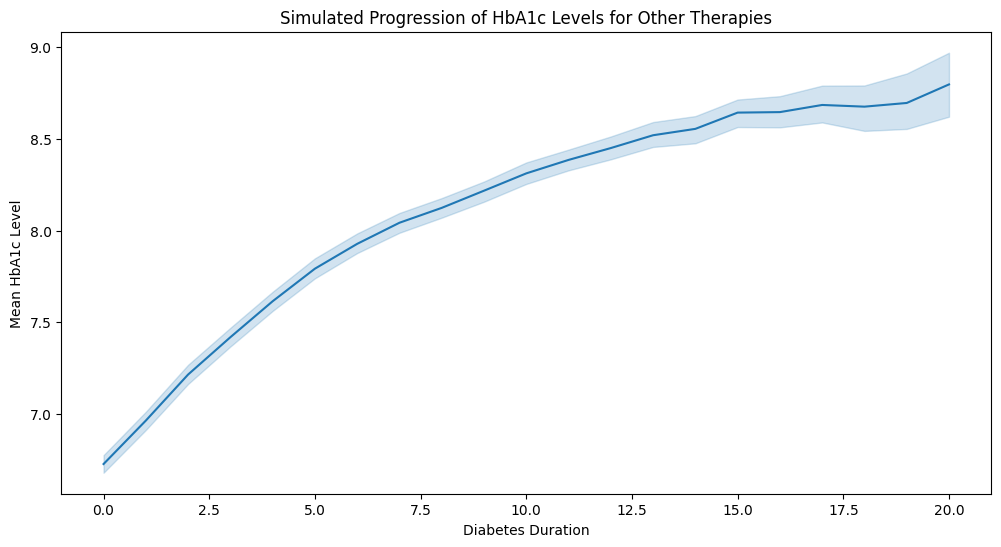

In [110]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', errorbar=('ci', 95), estimator='mean')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Simulated Progression of HbA1c Levels for Other Therapies')
plt.grid(False)
plt.show()

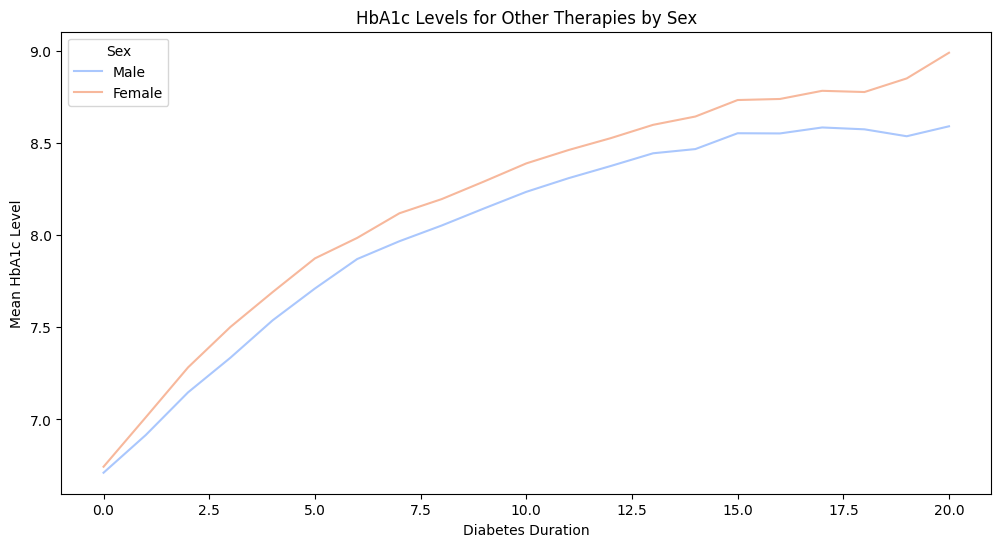

In [111]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Sex', errorbar=None, estimator='mean', palette='coolwarm')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('HbA1c Levels for Other Therapies by Sex')
plt.grid(False)
plt.legend(title='Sex', labels=sex_map.values())
plt.show()

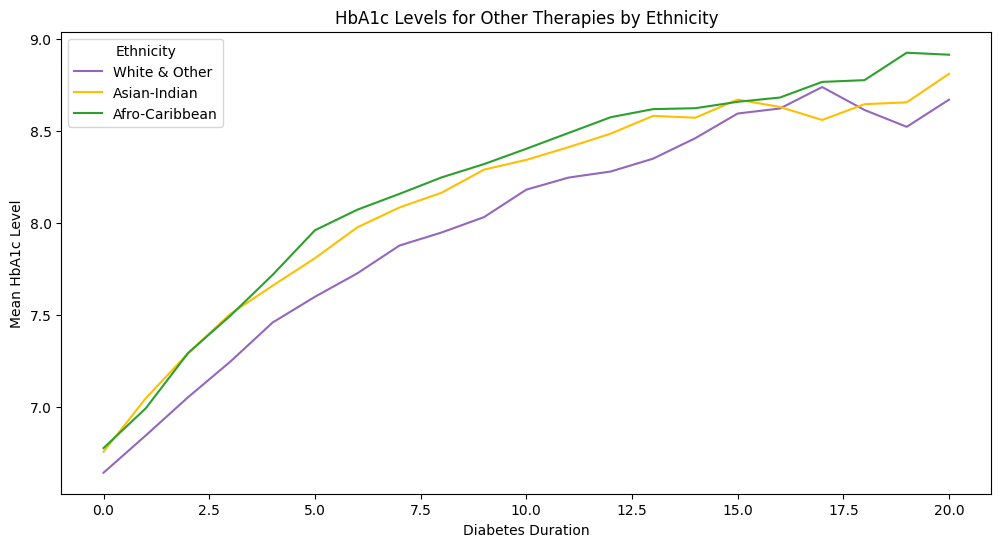

In [112]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Ethnicity', errorbar=None, estimator='mean', 
             palette=custom_palette, hue_order=[0, 1, 2])
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('HbA1c Levels for Other Therapies by Ethnicity')
plt.grid(False)
plt.legend(
    title='Ethnicity',
    labels=[ethnicity_map[i] for i in [0, 1, 2]])
plt.show()

### EFFICIENCY OF INTERVENTION (BETA) ANALYSIS

##### INDIVIDUAL-LEVEL HAZARD RATE

In [113]:
# ---------------------------------------------------------------------------
# Assumes `df` already exists in the notebook from the user's HbA1c simulation
# ---------------------------------------------------------------------------
try:
    df
except NameError:
    raise RuntimeError(
        "The DataFrame `df` was not found. "
        "Please run your HbA1c simulation code first, "
        "so that `df` containing the columns "
        "['Bootstrap', 'Year', 'Diabetes_Duration', 'Patient_ID', "
        "'Sex', 'Ethnicity', 'HbA1c'] is defined."
    )

# 1.  Screen HbA1c (H) per patient  ------------------------------------------
screen_H = (
    df.loc[df["Year"] == 1, ["Patient_ID", "HbA1c"]]
      .set_index("Patient_ID")["HbA1c"]
)

# 2.  Sort for cumulative calculations
df_sorted = df.sort_values(["Patient_ID", "Year"]).copy()

# 3.  Cumulative mean HbA1c (A) for each patient up to current year ----------
df_sorted["CumMean_HbA1c"] = (
    df_sorted.groupby("Patient_ID")["HbA1c"]
             .expanding()
             .mean()
             .reset_index(level=0, drop=True)
)

# 4.  Merge screen_H into df_sorted so every row has H ------------------------
df_sorted["Screen_HbA1c"] = df_sorted["Patient_ID"].map(screen_H)

# 5.  Hazard calculation parameters (DCCT Poisson model) ---------------------
ALPHA = -10.682
B1 = 0.201
B2 = 0.561
B3 = -1.228
B4 = 1.709
B5 = 0.686

# 6.  Compute hazard λ_it -----------------------------------------------------
#    D = Year, t = Diabetes_Duration, A = CumMean_HbA1c
ln_D = np.log(df_sorted["Year"])
ln_A = np.log(df_sorted["CumMean_HbA1c"])

df_sorted["Hazard"] = np.exp(
    ALPHA +
    B1 * df_sorted["Screen_HbA1c"] +
    B2 * ln_D +
    B3 * df_sorted["Diabetes_Duration"] +
    B4 * ln_A +
    B5 * df_sorted["Diabetes_Duration"] * ln_A
)

# 7.  Collect output DataFrame as requested -----------------------------------
hazard_df = df_sorted[[
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID",
    "Sex", "Ethnicity", "CumMean_HbA1c", "Hazard"
]].reset_index(drop=True)

# hazard_df.to_csv("hazard_df.csv", index=False)

In [114]:
# Compute average hazard rate per study year (diabetes duration)
avg_hazard_diabetes_duration = (
    hazard_df.groupby("Diabetes_Duration", as_index=False)["Hazard"]
             .mean()
             .rename(columns={"Hazard": "Mean_Hazard"})
)
print(avg_hazard_diabetes_duration)

    Diabetes_Duration  Mean_Hazard
0                   0     0.002864
1                   1     0.005119
2                   2     0.007983
3                   3     0.011955
4                   4     0.017597
5                   5     0.025615
6                   6     0.036956
7                   7     0.053660
8                   8     0.077206
9                   9     0.110741
10                 10     0.158829
11                 11     0.229454
12                 12     0.333542
13                 13     0.479241
14                 14     0.688179
15                 15     1.001846
16                 16     1.447964
17                 17     2.004425
18                 18     3.009175
19                 19     4.548725
20                 20     7.573414


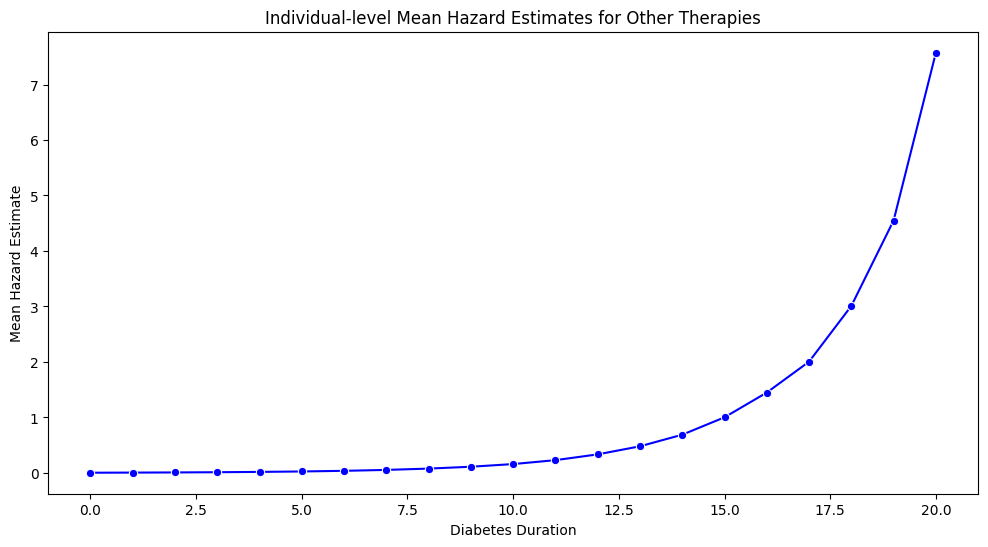

In [115]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_hazard_diabetes_duration, x='Diabetes_Duration', y='Mean_Hazard', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Hazard Estimate')
plt.title('Individual-level Mean Hazard Estimates for Other Therapies')
plt.grid(False)
plt.show()

##### INDIVIDUAL-LEVEL PROBABLITY OF HAVING A CHRONIC DISEASE

In [116]:
# 1. Copy relevant columns so we keep the original frame intact
probability_df = hazard_df.copy()

# 2. Probability of disease event in year t for each patient
#    P = 1 - exp(-rate * time),  where time = Year (1…21) and rate = Hazard
probability_df["Probability"] = 1.0 - np.exp(
    - probability_df["Hazard"] * probability_df["Year"]
)

# 3. Keep only necessary columns (add others if you need them)
probability_df = probability_df[[
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID", "Probability"
]]

# probability_df.to_csv("probability_df.csv", index=False)

In [117]:
# Compute average probability per study year (diabetes duration)
avg_probability_diabetes_duration = (
    probability_df.groupby("Diabetes_Duration", as_index=False)["Probability"]
             .mean()
             .rename(columns={"Probability": "Mean_Probability"})
)
print(avg_probability_diabetes_duration)

    Diabetes_Duration  Mean_Probability
0                   0          0.002858
1                   1          0.010144
2                   2          0.023392
3                   3          0.045419
4                   4          0.079406
5                   5          0.127650
6                   6          0.189728
7                   7          0.264949
8                   8          0.346981
9                   9          0.429230
10                 10          0.512458
11                 11          0.589832
12                 12          0.658022
13                 13          0.714252
14                 14          0.763094
15                 15          0.808499
16                 16          0.842345
17                 17          0.870789
18                 18          0.894036
19                 19          0.912008
20                 20          0.919205


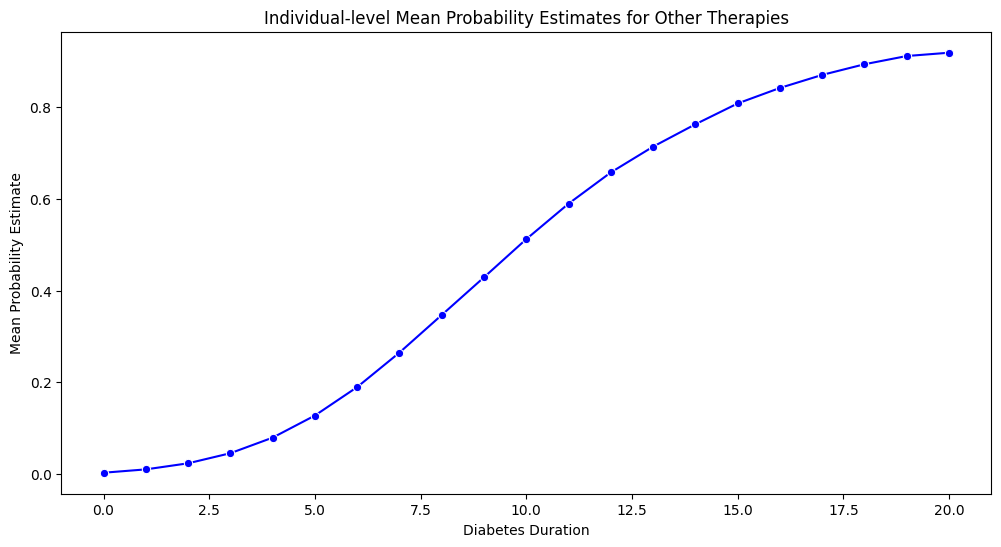

In [118]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_probability_diabetes_duration, x='Diabetes_Duration', y='Mean_Probability', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Probability Estimate')
plt.title('Individual-level Mean Probability Estimates for Other Therapies')
plt.grid(False)
plt.show()

##### INDIVIDUAL-LEVEL THERAPY/INTERVENTION EFFICIENCY

In [119]:
# 1. Merge hazard rates with corresponding HbA1c values -----------------------
merged = (
    hazard_df.merge(
        df[["Bootstrap", "Year", "Patient_ID", "HbA1c"]],
        on=["Bootstrap", "Year", "Patient_ID"],
        how="left",
        validate="one_to_one",
        suffixes=("", "_RiskFactor")
    )
)

# 2. Sort for lag calculations -------------------------------------------------
merged = merged.sort_values(["Patient_ID", "Year"]).copy()

# 3. Add previous-year values within each patient -----------------------------
merged["Hazard_prev"] = merged.groupby("Patient_ID")["Hazard"].shift(1)
merged["HbA1c_prev"]  = merged.groupby("Patient_ID")["HbA1c"].shift(1)

# 4. Calculate beta (skip Year==1 where prev is NaN) ---------------------------
def safe_beta(row):
    h_prev, h_cur = row["Hazard_prev"], row["Hazard"]
    a_prev, a_cur = row["HbA1c_prev"], row["HbA1c"]
    if pd.isna(h_prev) or pd.isna(a_prev):
        return np.nan
    if a_cur == a_prev or h_prev <= 0 or h_cur <= 0:
        return np.nan
    return np.log(h_cur / h_prev) / np.log(a_cur / a_prev)

merged["Beta"] = merged.apply(safe_beta, axis=1)

# 5. Prepare final beta DataFrame (exclude Year 1) -----------------------------
beta_df = merged.loc[merged["Year"] > 1, [
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID", "Beta"
]].reset_index(drop=True)

#beta_df.to_csv("beta_df.csv", index=False)

In [120]:
# Compute average beta values per study year (diabetes duration)
avg_beta_diabetes_duration = (
    beta_df.groupby("Diabetes_Duration", as_index=False)["Beta"]
             .mean()
             .rename(columns={"Beta": "Mean_Beta"})
)
print(avg_beta_diabetes_duration)

    Diabetes_Duration   Mean_Beta
0                   1  315.336156
1                   2    5.039928
2                   3   -0.282508
3                   4    9.079455
4                   5   -1.922630
5                   6    2.599695
6                   7  -12.440863
7                   8   -0.021361
8                   9   -2.185176
9                  10    0.232195
10                 11   15.234850
11                 12    1.813646
12                 13   -3.094039
13                 14   -2.738746
14                 15   -1.481653
15                 16    1.320834
16                 17   -0.780815
17                 18    0.137622
18                 19    1.464387
19                 20   -0.630709


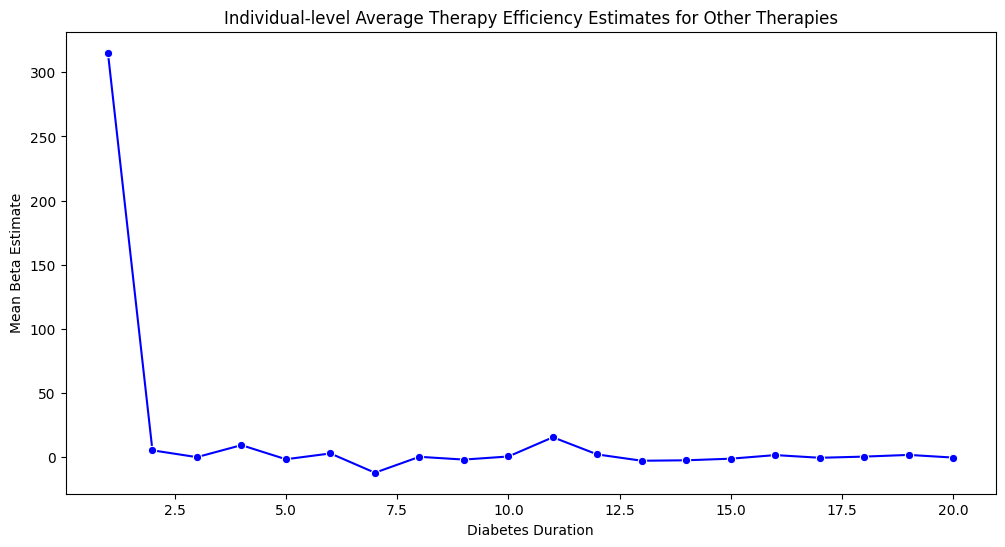

In [121]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_beta_diabetes_duration, x='Diabetes_Duration', y='Mean_Beta', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Beta Estimate')
plt.title('Individual-level Average Therapy Efficiency Estimates for Other Therapies')
plt.grid(False)
plt.show()

### POPULATION-LEVEL HAZARD RATE/PROBABILITY/INTERVENTION EFFICIENCY

In [122]:
avg_df = avg_HbA1c_diabetes_duration.copy()

# harmonise column names
if "Avg_HbA1c" not in avg_df.columns:
    # try to detect the HbA1c column
    hba1c_col = [c for c in avg_df.columns if "HbA1c" in c][0]
    avg_df = avg_df.rename(columns={hba1c_col: "Avg_HbA1c"})

# Ensure Diabetes_Duration integer & sorted
avg_df["Diabetes_Duration"] = avg_df["Diabetes_Duration"].astype(int)
avg_df = avg_df.sort_values("Diabetes_Duration").reset_index(drop=True)

# ---------------------------------------------------------------------------
# 1. cumulative mean HbA1c (A) across durations for the population
avg_df["CumMean_HbA1c"] = avg_df["Avg_HbA1c"].expanding().mean()

# 2. baseline H (duration 0 average)
baseline_H = float(avg_df.loc[avg_df["Diabetes_Duration"] == 0, "Avg_HbA1c"].iloc[0])

# 3. Hazard calculation parameters
ALPHA = -10.682
B1 = 0.201
B2 = 0.561
B3 = -1.228
B4 = 1.709
B5 = 0.686

# 4. Calculate hazard for each duration
#    D = Year = duration + 1
avg_df["Year"] = avg_df["Diabetes_Duration"] + 1
avg_df["ln_D"] = np.log(avg_df["Year"])
avg_df["ln_A"] = np.log(avg_df["CumMean_HbA1c"])

avg_df["Hazard"] = np.exp(
    ALPHA +
    B1 * baseline_H +
    B2 * avg_df["ln_D"] +
    B3 * avg_df["Diabetes_Duration"] +
    B4 * avg_df["ln_A"] +
    B5 * avg_df["Diabetes_Duration"] * avg_df["ln_A"]
)

# 5. Beta calculation (skip first duration)
haz_prev = avg_df["Hazard"].shift(1)
Hb_prev  = avg_df["Avg_HbA1c"].shift(1)

beta_vals = np.where(
    (avg_df["Diabetes_Duration"] == 0) | (haz_prev <= 0) | (avg_df["Hazard"] <= 0) |
    (avg_df["Avg_HbA1c"] == Hb_prev),
    np.nan,
    np.log(avg_df["Hazard"] / haz_prev) / np.log(avg_df["Avg_HbA1c"] / Hb_prev)
)

avg_df["Beta"] = beta_vals

# Keep desired columns
pop_hazard_beta_df = avg_df[[
    "Diabetes_Duration", "Year", "Avg_HbA1c", "CumMean_HbA1c",
    "Hazard", "Beta"
]]

avg_df["Probability"] = 1.0 - np.exp(
    - pop_hazard_beta_df["Hazard"] * pop_hazard_beta_df["Year"]
)

pop_hazard_beta_df = avg_df[[
    "Diabetes_Duration", "Year", "Avg_HbA1c", "CumMean_HbA1c",
    "Hazard", "Probability", "Beta"
]]

In [123]:
print(pop_hazard_beta_df)

    Diabetes_Duration  Year  Avg_HbA1c  CumMean_HbA1c    Hazard  Probability  \
0                   0     1   6.727085       6.727085  0.002306     0.002303   
1                   1     2   6.963902       6.845493  0.003841     0.007653   
2                   2     3   7.215044       6.968677  0.005583     0.016610   
3                   3     4   7.418488       7.081130  0.007731     0.030451   
4                   4     5   7.614602       7.187824  0.010505     0.051169   
5                   5     6   7.792255       7.288563  0.014164     0.081473   
6                   6     7   7.927614       7.379856  0.018997     0.124518   
7                   7     8   8.042704       7.462712  0.025408     0.183934   
8                   8     9   8.123781       7.536164  0.033866     0.262726   
9                   9    10   8.217459       7.604293  0.045150     0.363329   
10                 10    11   8.311878       7.668619  0.060301     0.484855   
11                 11    12   8.385256  

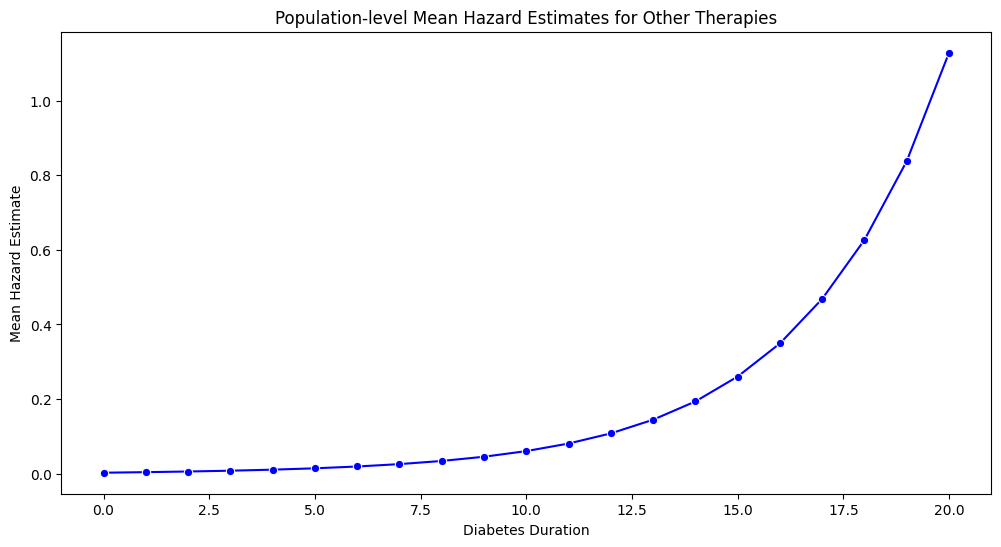

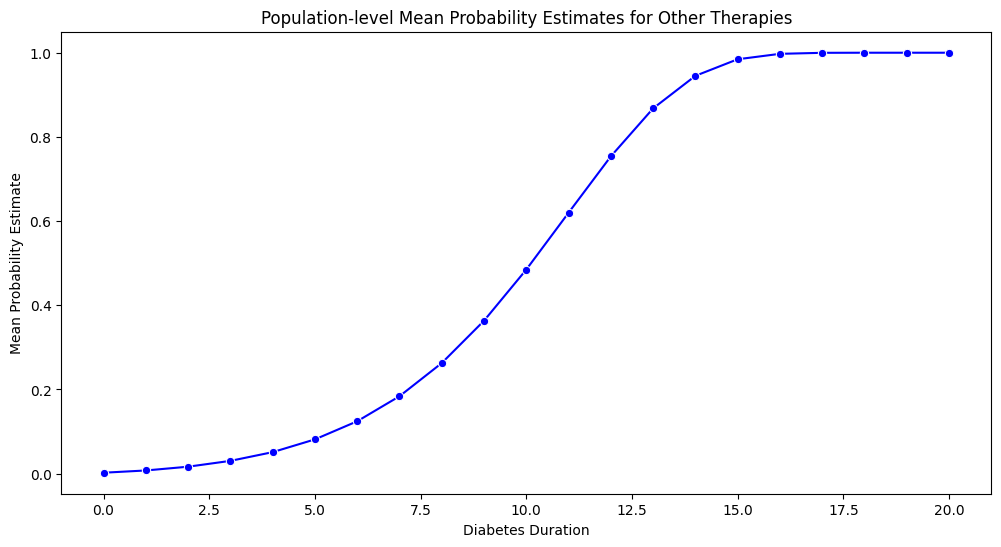

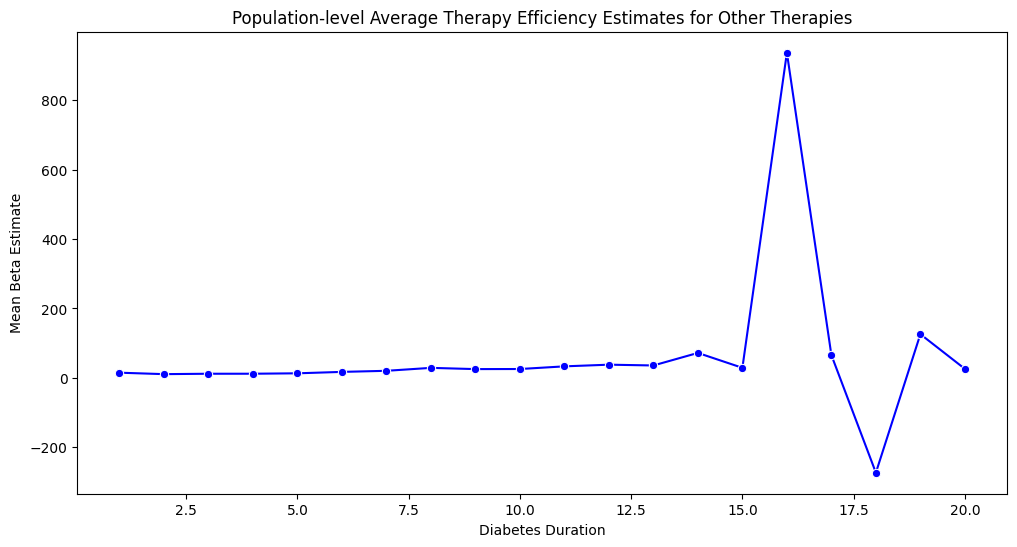

In [124]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Hazard', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Hazard Estimate')
plt.title('Population-level Mean Hazard Estimates for Other Therapies')
plt.grid(False)
plt.show()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Probability', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Probability Estimate')
plt.title('Population-level Mean Probability Estimates for Other Therapies')
plt.grid(False)
plt.show()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Beta', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Beta Estimate')
plt.title('Population-level Average Therapy Efficiency Estimates for Other Therapies')
plt.grid(False)
plt.show()

### SENSITIVITY ANALYSIS FOR OTHER THERAPY METHODS

##### trial for article_1

In [125]:
phi_3 = -0.014
beta_ethnicity = [0.082, 0.063]

all_bootstrap_data = []

for b in range(num_bootstraps):
    data = []

    # Active patient list starts with everyone
    active_patients = set(patient_ids)

    # Store past values per patient
    patient_history = {pid: year_1[i] for i, pid in enumerate(patient_ids)}
    
    for t in range(1, num_years + 1):
        
        new_active_patients = set()                      # Keep track of patients who stay
        
        for i in list(active_patients):                  # Iterate over active patients only
            
            y_prev = patient_history[patient_ids[i]]     # Retrieve last year's value
            
            diabetes_duration = np.log(t) if t > 1 else 0
            
            # Assign ethnicity effect correctly
            ethnicity_effect = beta_ethnicity[ethnicity[i] - 1] if ethnicity[i] > 0 else 0
            
            # Compute new risk factor value
            y_new = (
                phi_0 + phi_1 * y_prev + gamma * diabetes_duration +
                phi_2 * year_1[i] + phi_3 * sex[i] + ethnicity_effect 
                # + mu[i] 
                + np.random.normal(0, sigma)  # Add noise
            )
            
            # Store results
            data.append({
                'Bootstrap': b + 1, 'Patient_ID': patient_ids[i], 'Year': t, 'Sex': sex[i],
                'Ethnicity': ethnicity[i], 'Diabetes_Duration': t-1, 'HbA1c': y_new
            })
            
            # Update patient's previous value for next iteration
            patient_history[patient_ids[i]] = y_new
                        
            # Apply dropout condition dynamically based on year
            if np.random.rand() > dropout_rates[t]:  # Keep patient if they don't drop out
                new_active_patients.add(i)
                        
        # Update active patients list for next year
        active_patients = new_active_patients
    
    all_bootstrap_data.extend(data)

df = pd.DataFrame(all_bootstrap_data)

In [126]:
# Compute average HbA1c level per study year (diabetes duration)
avg_HbA1c_diabetes_duration = (
    df.groupby("Diabetes_Duration", as_index=False)["HbA1c"]
             .mean()
             .rename(columns={"HbA1c": "Mean_HbA1c"})
)
print(avg_HbA1c_diabetes_duration)

    Diabetes_Duration  Mean_HbA1c
0                   0    6.667196
1                   1    6.917553
2                   2    7.143564
3                   3    7.358527
4                   4    7.522498
5                   5    7.660514
6                   6    7.838038
7                   7    7.956941
8                   8    8.047914
9                   9    8.143452
10                 10    8.209503
11                 11    8.290902
12                 12    8.359715
13                 13    8.412435
14                 14    8.501638
15                 15    8.551369
16                 16    8.596821
17                 17    8.637881
18                 18    8.705811
19                 19    8.717491
20                 20    8.708862


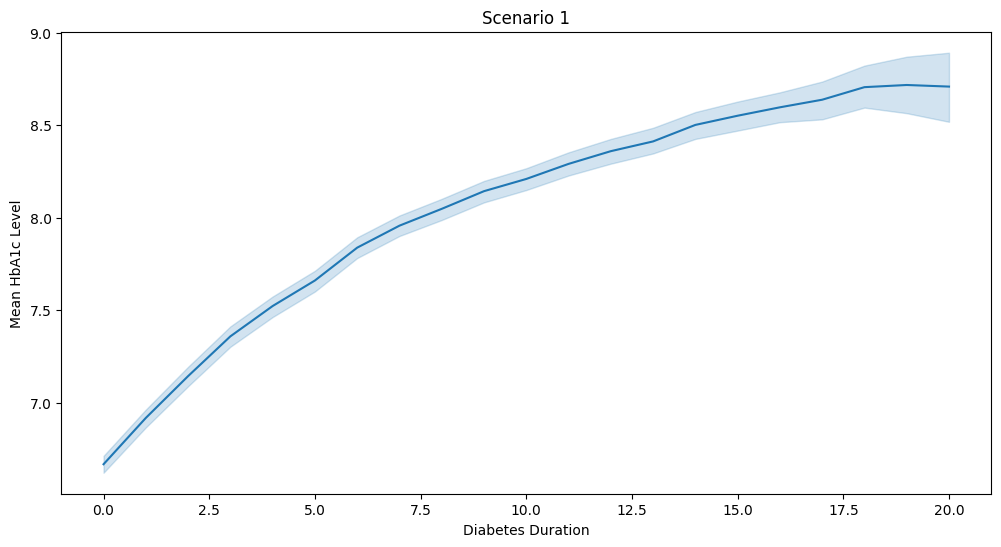

In [127]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', errorbar=('ci', 95), estimator='mean')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Scenario 1')
plt.grid(False)
plt.show()

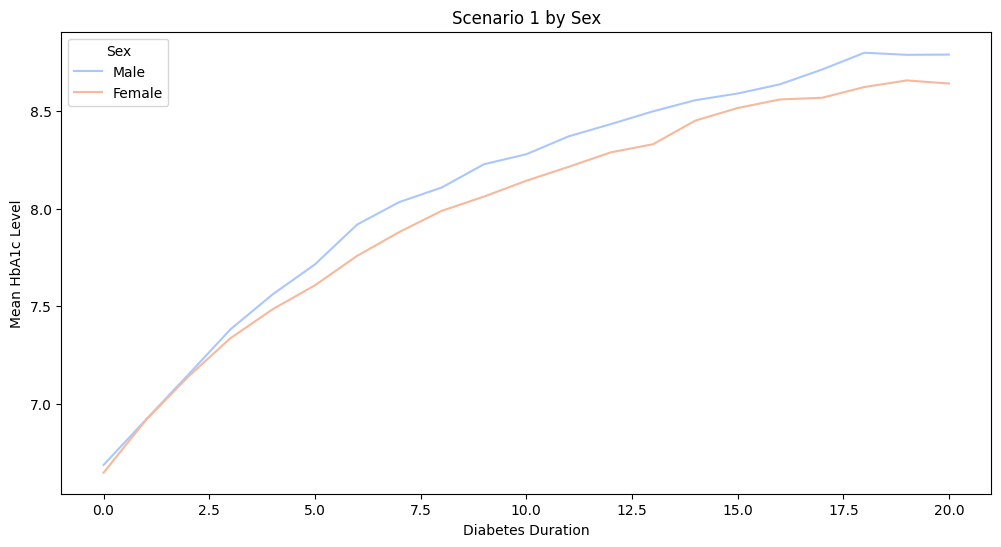

In [128]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Sex', errorbar=None, estimator='mean', palette='coolwarm')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Scenario 1 by Sex')
plt.grid(False)
plt.legend(title='Sex', labels=sex_map.values())
plt.show()

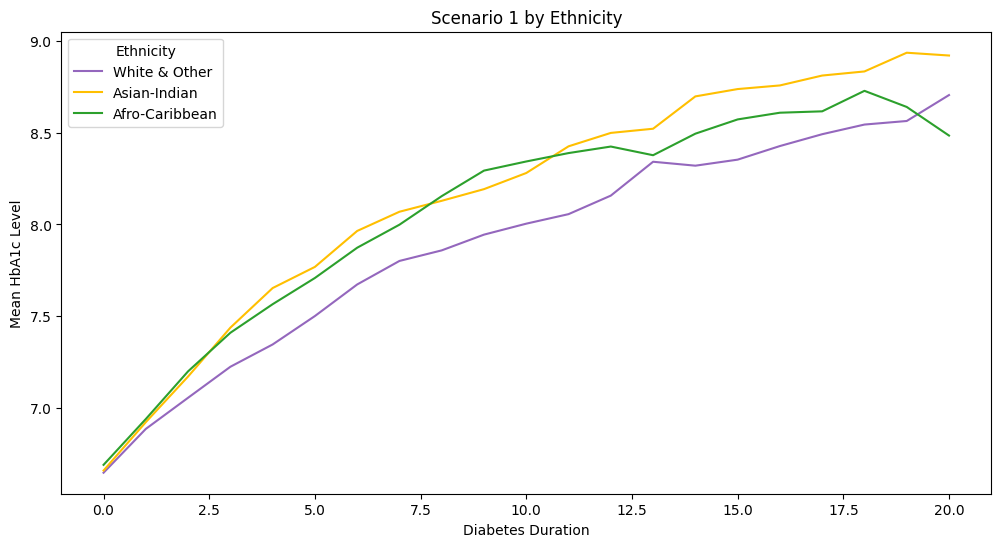

In [129]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Ethnicity', errorbar=None, estimator='mean', palette=custom_palette, hue_order=[0, 1, 2])
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Scenario 1 by Ethnicity')
plt.grid(False)
plt.legend(
    title='Ethnicity',
    labels=[ethnicity_map[i] for i in [0, 1, 2]])
plt.show()

##### trial for article_2

In [130]:
phi_3 = -0.012
beta_ethnicity = [0.035, 0.038]

all_bootstrap_data = []

for b in range(num_bootstraps):
    data = []

    # Active patient list starts with everyone
    active_patients = set(patient_ids)

    # Store past values per patient
    patient_history = {pid: year_1[i] for i, pid in enumerate(patient_ids)}
    
    for t in range(1, num_years + 1):
        
        new_active_patients = set()                      # Keep track of patients who stay
        
        for i in list(active_patients):                  # Iterate over active patients only
            
            y_prev = patient_history[patient_ids[i]]     # Retrieve last year's value
            
            diabetes_duration = np.log(t) if t > 1 else 0
            
            # Assign ethnicity effect correctly
            ethnicity_effect = beta_ethnicity[ethnicity[i] - 1] if ethnicity[i] > 0 else 0
            
            # Compute new risk factor value
            y_new = (
                phi_0 + phi_1 * y_prev + gamma * diabetes_duration +
                phi_2 * year_1[i] + phi_3 * sex[i] + ethnicity_effect 
                # + mu[i] 
                + np.random.normal(0, sigma)  # Add noise
            )
            
            # Store results
            data.append({
                'Bootstrap': b + 1, 'Patient_ID': patient_ids[i], 'Year': t, 'Sex': sex[i],
                'Ethnicity': ethnicity[i], 'Diabetes_Duration': t-1, 'HbA1c': y_new
            })
            
            # Update patient's previous value for next iteration
            patient_history[patient_ids[i]] = y_new
                        
            # Apply dropout condition dynamically based on year
            if np.random.rand() > dropout_rates[t]:  # Keep patient if they don't drop out
                new_active_patients.add(i)
                        
        # Update active patients list for next year
        active_patients = new_active_patients
    
    all_bootstrap_data.extend(data)

df = pd.DataFrame(all_bootstrap_data)

In [131]:
# Compute average HbA1c level per study year (diabetes duration)
avg_HbA1c_diabetes_duration = (
    df.groupby("Diabetes_Duration", as_index=False)["HbA1c"]
             .mean()
             .rename(columns={"HbA1c": "Mean_HbA1c"})
)
print(avg_HbA1c_diabetes_duration)

    Diabetes_Duration  Mean_HbA1c
0                   0    6.636142
1                   1    6.872436
2                   2    7.095374
3                   3    7.281751
4                   4    7.476422
5                   5    7.617823
6                   6    7.719976
7                   7    7.855388
8                   8    7.945846
9                   9    8.029671
10                 10    8.063995
11                 11    8.162341
12                 12    8.267088
13                 13    8.335744
14                 14    8.341875
15                 15    8.359794
16                 16    8.438837
17                 17    8.487244
18                 18    8.567380
19                 19    8.594892
20                 20    8.571084


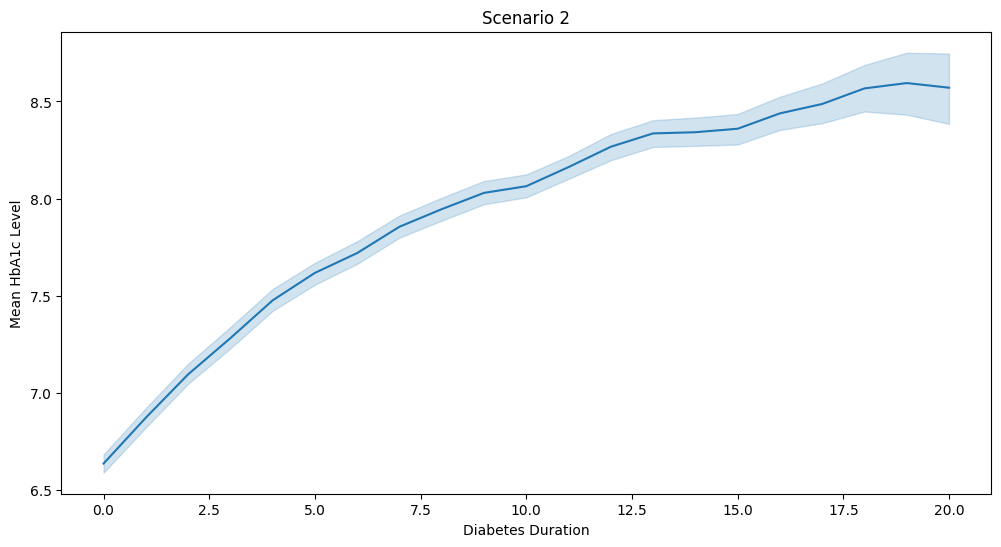

In [132]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', errorbar=('ci', 95), estimator='mean')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Scenario 2')
plt.grid(False)
plt.show()

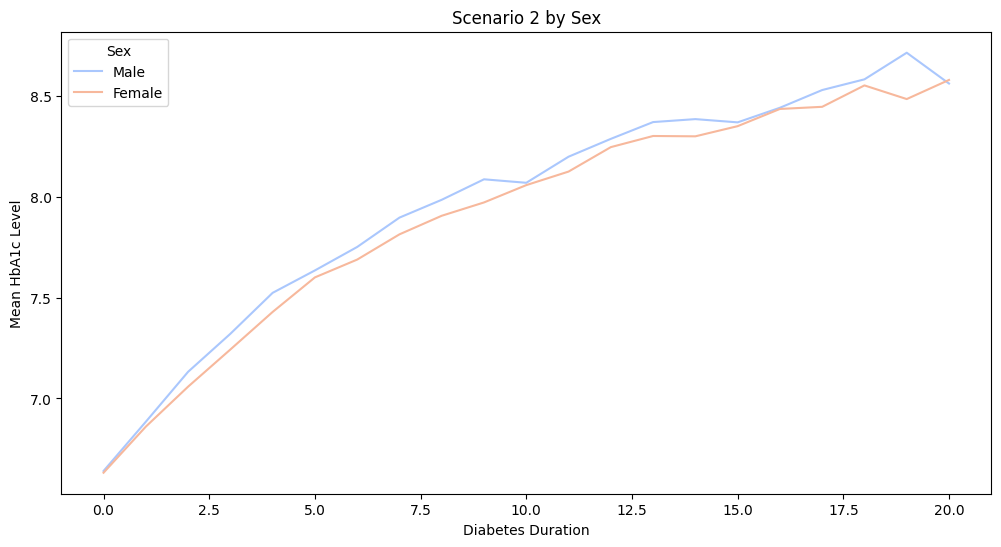

In [133]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Sex', errorbar=None, estimator='mean', palette='coolwarm')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Scenario 2 by Sex')
plt.grid(False)
plt.legend(title='Sex', labels=sex_map.values())
plt.show()

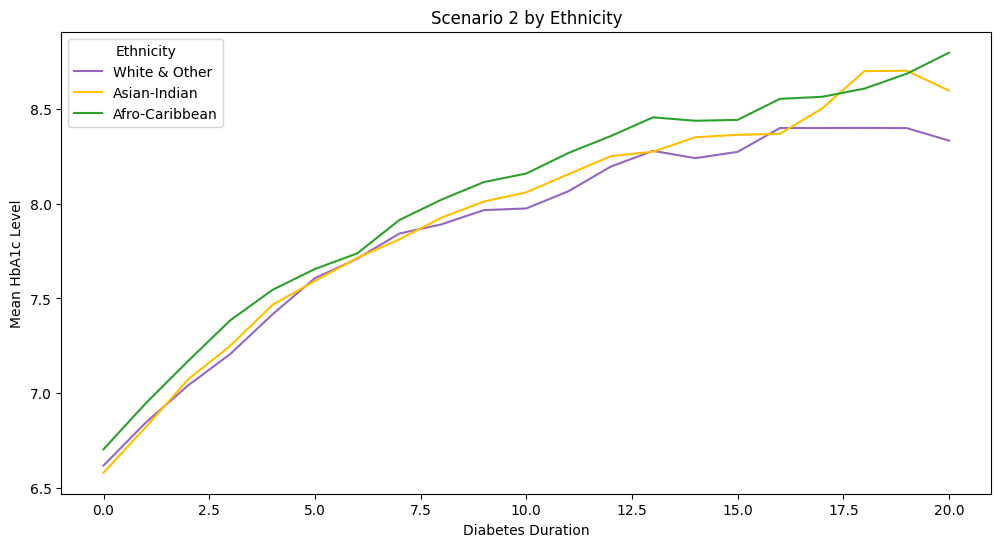

In [134]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Ethnicity', errorbar=None, estimator='mean', palette=custom_palette, hue_order=[0, 1, 2])
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Scenario 2 by Ethnicity')
plt.grid(False)
plt.legend(
    title='Ethnicity',
    labels=[ethnicity_map[i] for i in [0, 1, 2]])
plt.show()

# FOR DIET

In [135]:
# Set simulation parameters
num_patients = 1087
num_years = 21
num_bootstraps = 1

# Annual dropout probabilities for each period
dropout_rates = { 
    1:  0.02, 2:  0.02, 3:  0.02, 4:  0.02,  5:  0.02, 6:  0.02,
    7:  0.02, 8:  0.02, 9:  0.02, 10: 0.02, 11:  0.02,
    12: 0.02, 13: 0.02, 14: 0.02, 15: 0.02, 16:  0.02,   
    17: 0.02, 18: 0.02, 19: 0.02, 20: 0.02, 21:  0.02
}

# Provided means and SDs
means = [7.9]

sds = [1.4]

# actual estimates
phi_0 = 1.680
phi_1 = 0.679
gamma = 0.219
phi_2 = 0.089
phi_3 = 0.055
beta_ethnicity = [0.040, 0.063]

np.random.seed(42)
patient_ids = np.arange(num_patients)
sex = np.random.choice([0, 1], num_patients)                                  # 0=male, 1=female
ethnicity = np.random.choice([0, 1, 2], num_patients)                         # 0=reference, 1=Asian-Indian, 2=Afro-Caribbean
year_1 = np.random.normal(loc=means[0], scale=sds[0], size=num_patients)      # Initial HbA1c values

# (Calibrated) sigma
sigma = 1.0

all_bootstrap_data = []

for b in range(num_bootstraps):
    data = []

    # Active patient list starts with everyone
    active_patients = set(patient_ids)

    # Store past values per patient
    patient_history = {pid: year_1[i] for i, pid in enumerate(patient_ids)}
    
    for t in range(1, num_years + 1):
        
        new_active_patients = set()                      # Keep track of patients who stay
        
        for i in list(active_patients):                  # Iterate over active patients only
            
            y_prev = patient_history[patient_ids[i]]     # Retrieve last year's value
            
            diabetes_duration = np.log(t) if t > 1 else 0
            
            # Assign ethnicity effect correctly
            ethnicity_effect = beta_ethnicity[ethnicity[i] - 1] if ethnicity[i] > 0 else 0
            
            # Compute new risk factor value
            y_new = (
                phi_0 + phi_1 * y_prev + gamma * diabetes_duration +
                phi_2 * year_1[i] + phi_3 * sex[i] + ethnicity_effect  
                + np.random.normal(0, sigma)  # Add noise
            )
            
            # Store results
            data.append({
                'Bootstrap': b + 1, 'Year': t, 'Diabetes_Duration': t-1, 'Patient_ID': patient_ids[i], 'Sex': sex[i],
                'Ethnicity': ethnicity[i], 'HbA1c': y_new
            })
            
            # Update patient's previous value for next iteration
            patient_history[patient_ids[i]] = y_new
                        
            # Apply dropout condition dynamically based on year
            if np.random.rand() > dropout_rates[t]:  # Keep patient if they don't drop out
                new_active_patients.add(i)
                        
        # Update active patients list for next year
        active_patients = new_active_patients
    
    all_bootstrap_data.extend(data)

df = pd.DataFrame(all_bootstrap_data)
# df.to_csv("simulated_data.csv", index=False)
# print(df.head())

In [136]:
# Compute SD per year from model simulation to compare with provided SDs
model_sd = df.groupby('Diabetes_Duration')['HbA1c'].std().reset_index(name='Simulated_SD')
print(model_sd)

    Diabetes_Duration  Simulated_SD
0                   0      1.519747
1                   1      1.493634
2                   2      1.461086
3                   3      1.437714
4                   4      1.416319
5                   5      1.424286
6                   6      1.414194
7                   7      1.422736
8                   8      1.430186
9                   9      1.431561
10                 10      1.436735
11                 11      1.434263
12                 12      1.408701
13                 13      1.430124
14                 14      1.425192
15                 15      1.426675
16                 16      1.443102
17                 17      1.367883
18                 18      1.382835
19                 19      1.367774
20                 20      1.404708


In [137]:
# Compute average HbA1c level per study year (diabetes duration)
avg_HbA1c_diabetes_duration = (
    df.groupby("Diabetes_Duration", as_index=False)["HbA1c"]
             .mean()
             .rename(columns={"HbA1c": "Mean_HbA1c"})
)
print(avg_HbA1c_diabetes_duration)

    Diabetes_Duration  Mean_HbA1c
0                   0    7.844514
1                   1    7.908593
2                   2    8.064744
3                   3    8.205124
4                   4    8.429284
5                   5    8.536949
6                   6    8.687379
7                   7    8.754013
8                   8    8.888594
9                   9    8.976097
10                 10    9.080891
11                 11    9.220095
12                 12    9.280076
13                 13    9.333795
14                 14    9.349463
15                 15    9.440371
16                 16    9.405420
17                 17    9.450148
18                 18    9.477717
19                 19    9.516608
20                 20    9.574575


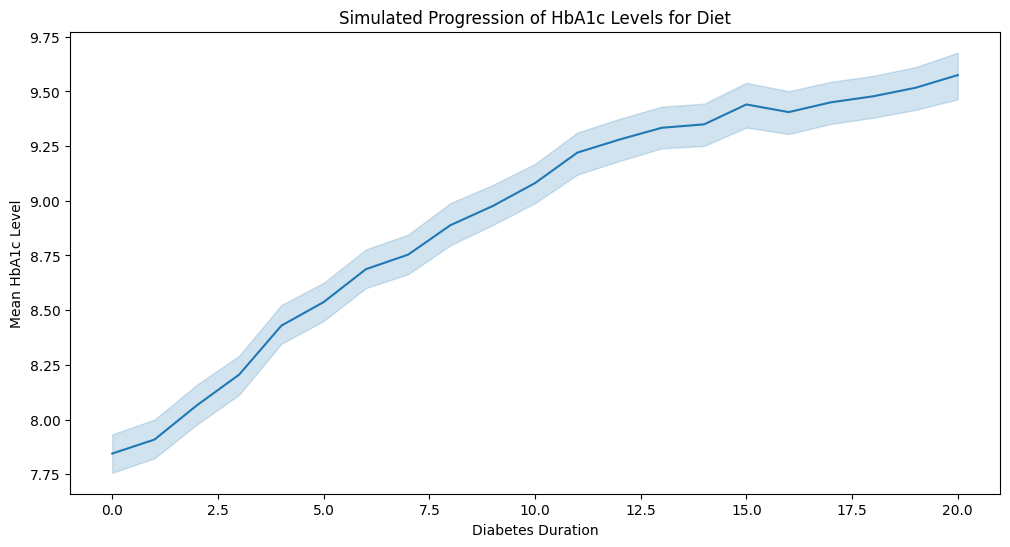

In [138]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', errorbar=('ci', 95), estimator='mean')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Simulated Progression of HbA1c Levels for Diet')
plt.grid(False)
plt.show()

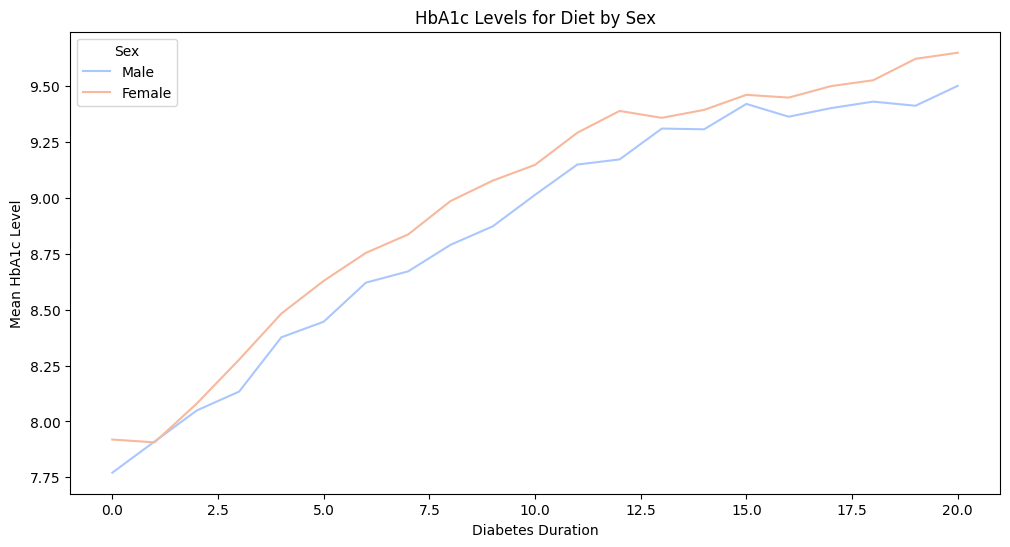

In [139]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Sex', errorbar=None, estimator='mean', palette='coolwarm')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('HbA1c Levels for Diet by Sex')
plt.grid(False)
plt.legend(title='Sex', labels=sex_map.values())
plt.show()

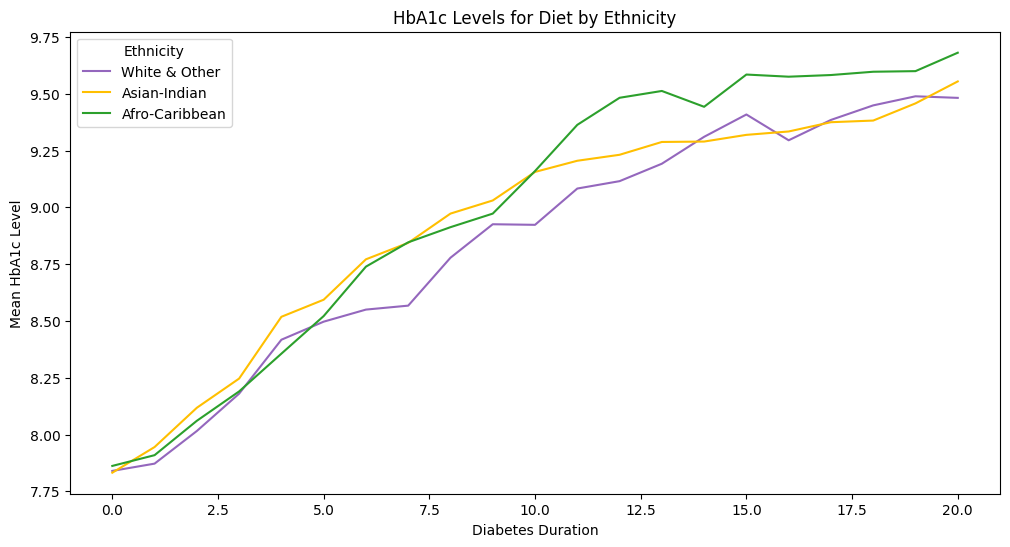

In [140]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Ethnicity', errorbar=None, estimator='mean', 
             palette=custom_palette, hue_order=[0, 1, 2])
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('HbA1c Levels for Diet by Ethnicity')
plt.grid(False)
plt.legend(
    title='Ethnicity',
    labels=[ethnicity_map[i] for i in [0, 1, 2]])
plt.show()

In [141]:
# ---------------------------------------------------------------------------
# Assumes `df` already exists in the notebook from the user's HbA1c simulation
# ---------------------------------------------------------------------------
try:
    df
except NameError:
    raise RuntimeError(
        "The DataFrame `df` was not found. "
        "Please run your HbA1c simulation code first, "
        "so that `df` containing the columns "
        "['Bootstrap', 'Year', 'Diabetes_Duration', 'Patient_ID', "
        "'Sex', 'Ethnicity', 'HbA1c'] is defined."
    )

# 1.  Screen HbA1c (H) per patient  ------------------------------------------
screen_H = (
    df.loc[df["Year"] == 1, ["Patient_ID", "HbA1c"]]
      .set_index("Patient_ID")["HbA1c"]
)

# 2.  Sort for cumulative calculations
df_sorted = df.sort_values(["Patient_ID", "Year"]).copy()

# 3.  Cumulative mean HbA1c (A) for each patient up to current year ----------
df_sorted["CumMean_HbA1c"] = (
    df_sorted.groupby("Patient_ID")["HbA1c"]
             .expanding()
             .mean()
             .reset_index(level=0, drop=True)
)

# 4.  Merge screen_H into df_sorted so every row has H ------------------------
df_sorted["Screen_HbA1c"] = df_sorted["Patient_ID"].map(screen_H)

# 5.  Hazard calculation parameters (DCCT Poisson model) ---------------------
ALPHA = -10.682
B1 = 0.201
B2 = 0.561
B3 = -1.228
B4 = 1.709
B5 = 0.686

# 6.  Compute hazard λ_it -----------------------------------------------------
#    D = Year, t = Diabetes_Duration, A = CumMean_HbA1c
ln_D = np.log(df_sorted["Year"])
ln_A = np.log(df_sorted["CumMean_HbA1c"])

df_sorted["Hazard"] = np.exp(
    ALPHA +
    B1 * df_sorted["Screen_HbA1c"] +
    B2 * ln_D +
    B3 * df_sorted["Diabetes_Duration"] +
    B4 * ln_A +
    B5 * df_sorted["Diabetes_Duration"] * ln_A
)

# 7.  Collect output DataFrame as requested -----------------------------------
hazard_df = df_sorted[[
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID",
    "Sex", "Ethnicity", "CumMean_HbA1c", "Hazard"
]].reset_index(drop=True)

# hazard_df.to_csv("hazard_df.csv", index=False)

In [142]:
# Compute average hazard rate per study year (diabetes duration)
avg_hazard_diabetes_duration = (
    hazard_df.groupby("Diabetes_Duration", as_index=False)["Hazard"]
             .mean()
             .rename(columns={"Hazard": "Mean_Hazard"})
)
print(avg_hazard_diabetes_duration)

    Diabetes_Duration  Mean_Hazard
0                   0     0.004432
1                   1     0.008359
2                   2     0.013577
3                   3     0.020909
4                   4     0.031572
5                   5     0.047162
6                   6     0.069659
7                   7     0.102989
8                   8     0.153279
9                   9     0.226931
10                 10     0.334798
11                 11     0.503966
12                 12     0.726240
13                 13     1.079572
14                 14     1.618053
15                 15     2.434990
16                 16     3.656078
17                 17     5.412377
18                 18     8.071908
19                 19    12.048723
20                 20    17.571873


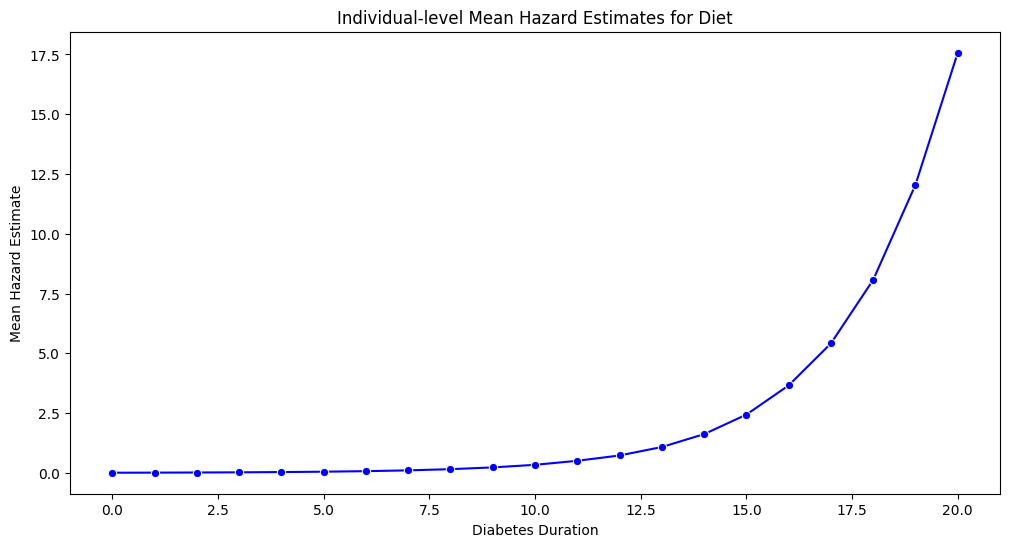

In [143]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_hazard_diabetes_duration, x='Diabetes_Duration', y='Mean_Hazard', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Hazard Estimate')
plt.title('Individual-level Mean Hazard Estimates for Diet')
plt.grid(False)
plt.show()

In [144]:
# 1. Copy relevant columns so we keep the original frame intact
probability_df = hazard_df.copy()

# 2. Probability of disease event in year t for each patient
#    P = 1 - exp(-rate * time),  where time = Year (1…21) and rate = Hazard
probability_df["Probability"] = 1.0 - np.exp(
    - probability_df["Hazard"] * probability_df["Year"]
)

# 3. Keep only necessary columns (add others if you need them)
probability_df = probability_df[[
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID", "Probability"
]]

# probability_df.to_csv("probability_df.csv", index=False)

In [145]:
# Compute average probability per study year (diabetes duration)
avg_probability_diabetes_duration = (
    probability_df.groupby("Diabetes_Duration", as_index=False)["Probability"]
             .mean()
             .rename(columns={"Probability": "Mean_Probability"})
)
print(avg_probability_diabetes_duration)

    Diabetes_Duration  Mean_Probability
0                   0          0.004417
1                   1          0.016495
2                   2          0.039287
3                   3          0.077352
4                   4          0.135805
5                   5          0.217440
6                   6          0.318695
7                   7          0.432619
8                   8          0.550032
9                   9          0.658386
10                 10          0.751948
11                 11          0.826065
12                 12          0.881106
13                 13          0.919382
14                 14          0.946740
15                 15          0.965214
16                 16          0.975779
17                 17          0.982710
18                 18          0.987823
19                 19          0.991805
20                 20          0.994082


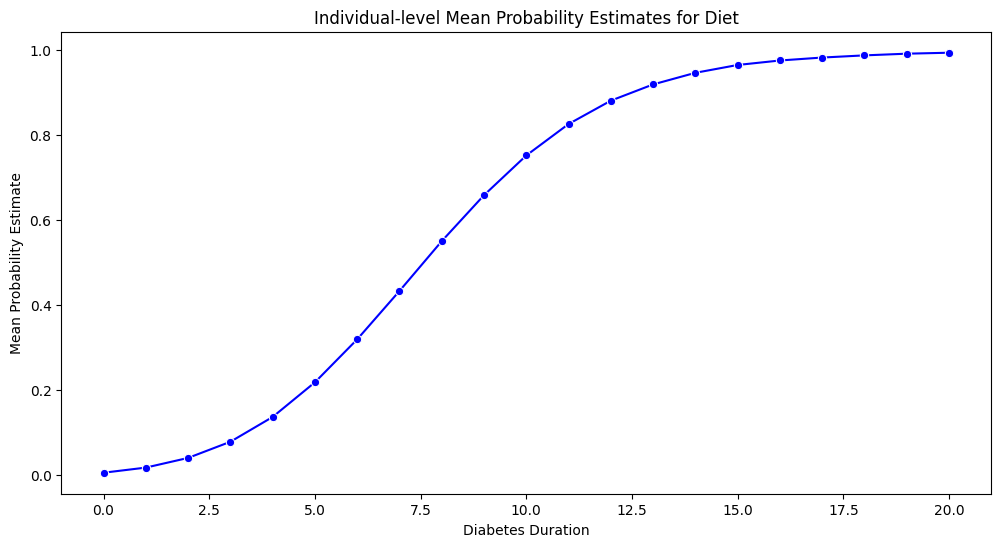

In [146]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_probability_diabetes_duration, x='Diabetes_Duration', y='Mean_Probability', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Probability Estimate')
plt.title('Individual-level Mean Probability Estimates for Diet')
plt.grid(False)
plt.show()

In [147]:
# 1. Merge hazard rates with corresponding HbA1c values -----------------------
merged = (
    hazard_df.merge(
        df[["Bootstrap", "Year", "Patient_ID", "HbA1c"]],
        on=["Bootstrap", "Year", "Patient_ID"],
        how="left",
        validate="one_to_one",
        suffixes=("", "_RiskFactor")
    )
)

# 2. Sort for lag calculations -------------------------------------------------
merged = merged.sort_values(["Patient_ID", "Year"]).copy()

# 3. Add previous-year values within each patient -----------------------------
merged["Hazard_prev"] = merged.groupby("Patient_ID")["Hazard"].shift(1)
merged["HbA1c_prev"]  = merged.groupby("Patient_ID")["HbA1c"].shift(1)

# 4. Calculate beta (skip Year==1 where prev is NaN) ---------------------------
def safe_beta(row):
    h_prev, h_cur = row["Hazard_prev"], row["Hazard"]
    a_prev, a_cur = row["HbA1c_prev"], row["HbA1c"]
    if pd.isna(h_prev) or pd.isna(a_prev):
        return np.nan
    if a_cur == a_prev or h_prev <= 0 or h_cur <= 0:
        return np.nan
    return np.log(h_cur / h_prev) / np.log(a_cur / a_prev)

merged["Beta"] = merged.apply(safe_beta, axis=1)

# 5. Prepare final beta DataFrame (exclude Year 1) -----------------------------
beta_df = merged.loc[merged["Year"] > 1, [
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID", "Beta"
]].reset_index(drop=True)

#beta_df.to_csv("beta_df.csv", index=False)

In [148]:
# Compute average beta values per study year (diabetes duration)
avg_beta_diabetes_duration = (
    beta_df.groupby("Diabetes_Duration", as_index=False)["Beta"]
             .mean()
             .rename(columns={"Beta": "Mean_Beta"})
)
print(avg_beta_diabetes_duration)

    Diabetes_Duration   Mean_Beta
0                   1   -1.631800
1                   2   -1.600981
2                   3   12.693895
3                   4  -10.565471
4                   5  -14.872282
5                   6    3.224154
6                   7    3.089273
7                   8    6.483027
8                   9    4.777667
9                  10   47.333423
10                 11    3.103223
11                 12   -4.163068
12                 13   -2.123039
13                 14    9.431163
14                 15    6.565360
15                 16    0.252880
16                 17   -1.890705
17                 18   20.480711
18                 19  123.436694
19                 20   20.690872


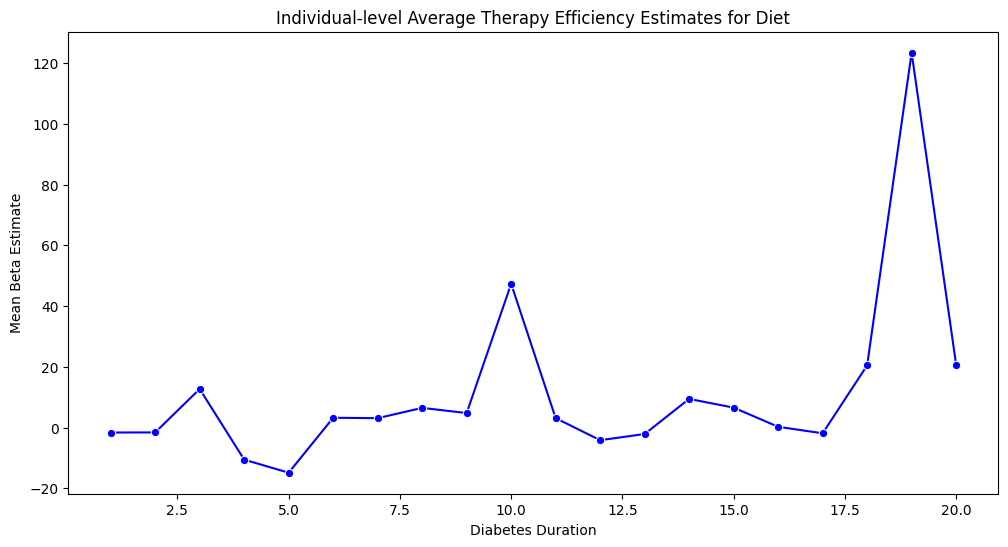

In [149]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_beta_diabetes_duration, x='Diabetes_Duration', y='Mean_Beta', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Beta Estimate')
plt.title('Individual-level Average Therapy Efficiency Estimates for Diet')
plt.grid(False)
plt.show()

In [150]:
avg_df = avg_HbA1c_diabetes_duration.copy()

# harmonise column names
if "Avg_HbA1c" not in avg_df.columns:
    # try to detect the HbA1c column
    hba1c_col = [c for c in avg_df.columns if "HbA1c" in c][0]
    avg_df = avg_df.rename(columns={hba1c_col: "Avg_HbA1c"})

# Ensure Diabetes_Duration integer & sorted
avg_df["Diabetes_Duration"] = avg_df["Diabetes_Duration"].astype(int)
avg_df = avg_df.sort_values("Diabetes_Duration").reset_index(drop=True)

# ---------------------------------------------------------------------------
# 1. cumulative mean HbA1c (A) across durations for the population
avg_df["CumMean_HbA1c"] = avg_df["Avg_HbA1c"].expanding().mean()

# 2. baseline H (duration 0 average)
baseline_H = float(avg_df.loc[avg_df["Diabetes_Duration"] == 0, "Avg_HbA1c"].iloc[0])

# 3. Hazard calculation parameters
ALPHA = -10.682
B1 = 0.201
B2 = 0.561
B3 = -1.228
B4 = 1.709
B5 = 0.686

# 4. Calculate hazard for each duration
#    D = Year = duration + 1
avg_df["Year"] = avg_df["Diabetes_Duration"] + 1
avg_df["ln_D"] = np.log(avg_df["Year"])
avg_df["ln_A"] = np.log(avg_df["CumMean_HbA1c"])

avg_df["Hazard"] = np.exp(
    ALPHA +
    B1 * baseline_H +
    B2 * avg_df["ln_D"] +
    B3 * avg_df["Diabetes_Duration"] +
    B4 * avg_df["ln_A"] +
    B5 * avg_df["Diabetes_Duration"] * avg_df["ln_A"]
)

# 5. Beta calculation (skip first duration)
haz_prev = avg_df["Hazard"].shift(1)
Hb_prev  = avg_df["Avg_HbA1c"].shift(1)

beta_vals = np.where(
    (avg_df["Diabetes_Duration"] == 0) | (haz_prev <= 0) | (avg_df["Hazard"] <= 0) |
    (avg_df["Avg_HbA1c"] == Hb_prev),
    np.nan,
    np.log(avg_df["Hazard"] / haz_prev) / np.log(avg_df["Avg_HbA1c"] / Hb_prev)
)

avg_df["Beta"] = beta_vals

# Keep desired columns
pop_hazard_beta_df = avg_df[[
    "Diabetes_Duration", "Year", "Avg_HbA1c", "CumMean_HbA1c",
    "Hazard", "Beta"
]]

avg_df["Probability"] = 1.0 - np.exp(
    - pop_hazard_beta_df["Hazard"] * pop_hazard_beta_df["Year"]
)

pop_hazard_beta_df = avg_df[[
    "Diabetes_Duration", "Year", "Avg_HbA1c", "CumMean_HbA1c",
    "Hazard", "Probability", "Beta"
]]

print(pop_hazard_beta_df)

    Diabetes_Duration  Year  Avg_HbA1c  CumMean_HbA1c    Hazard  Probability  \
0                   0     1   7.844514       7.844514  0.003754     0.003747   
1                   1     2   7.908593       7.876553  0.006729     0.013367   
2                   2     3   8.064744       7.939284  0.010445     0.030849   
3                   3     4   8.205124       8.005744  0.015366     0.059614   
4                   4     5   8.429284       8.090452  0.022269     0.105372   
5                   5     6   8.536949       8.164868  0.031778     0.173591   
6                   6     7   8.687379       8.239512  0.045184     0.271150   
7                   7     8   8.754013       8.303825  0.063753     0.399517   
8                   8     9   8.888594       8.368799  0.090129     0.555660   
9                   9    10   8.976097       8.429529  0.127328     0.720088   
10                 10    11   9.080891       8.488744  0.180295     0.862378   
11                 11    12   9.220095  

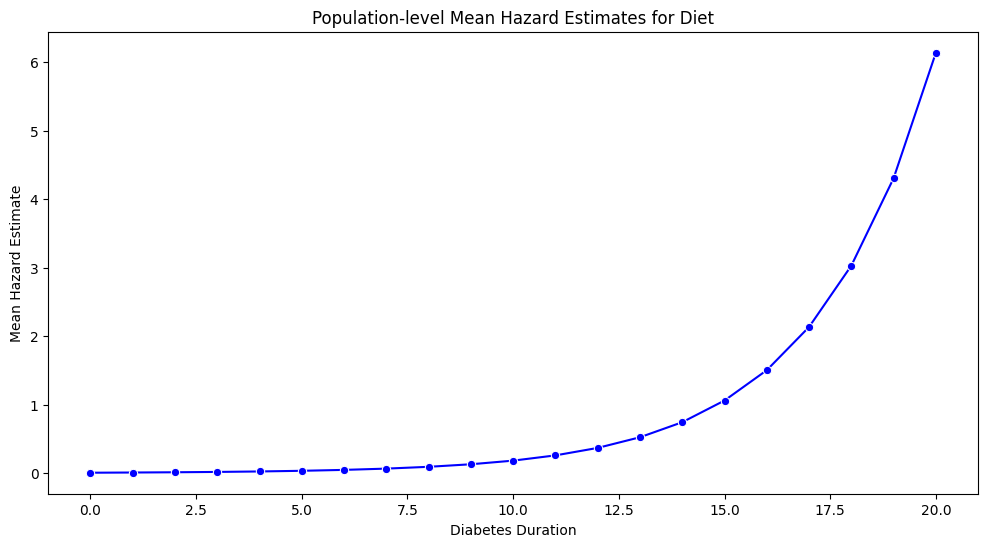

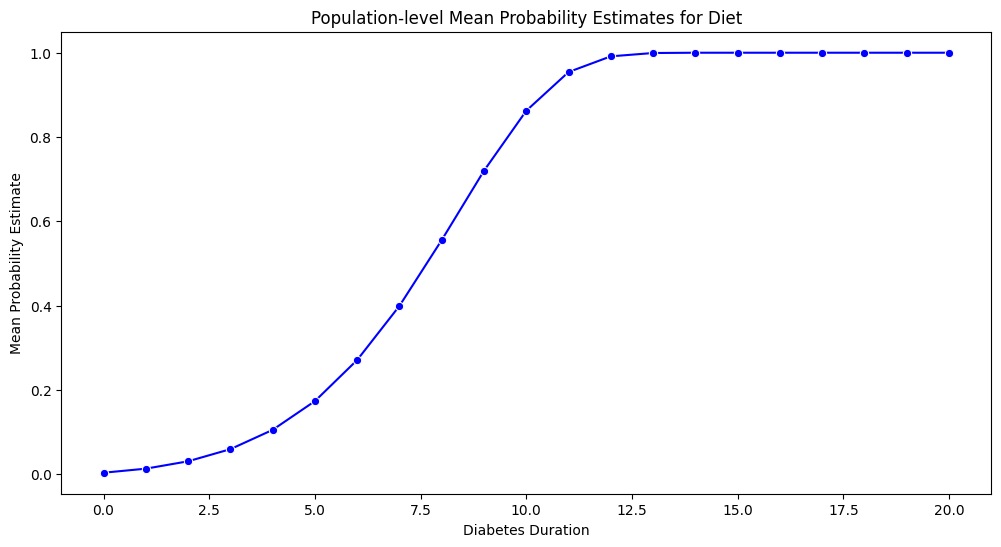

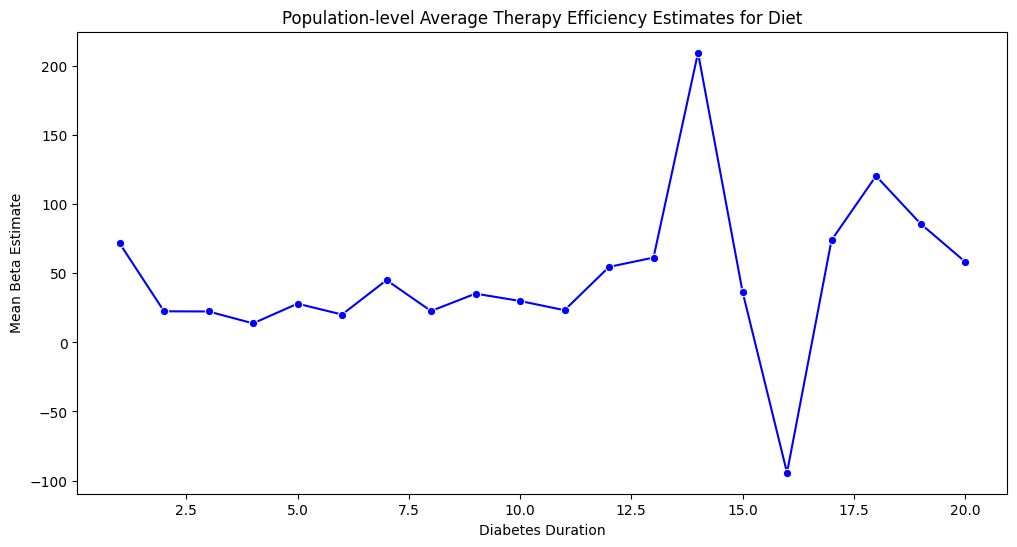

In [151]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Hazard', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Hazard Estimate')
plt.title('Population-level Mean Hazard Estimates for Diet')
plt.grid(False)
plt.show()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Probability', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Probability Estimate')
plt.title('Population-level Mean Probability Estimates for Diet')
plt.grid(False)
plt.show()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Beta', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Beta Estimate')
plt.title('Population-level Average Therapy Efficiency Estimates for Diet')
plt.grid(False)
plt.show()

# FOR INSULIN

In [152]:
# Set simulation parameters
num_patients = 1341
num_years = 21
num_bootstraps = 1

# Annual dropout probabilities for each period
dropout_rates = { 
    1:  0.015, 2:  0.015, 3:  0.015, 4:  0.015,  5:  0.015, 6:  0.015,
    7:  0.015, 8:  0.015, 9:  0.015, 10: 0.015, 11:  0.015,
    12: 0.015, 13: 0.015, 14: 0.015, 15: 0.015, 16:  0.015,   
    17: 0.015, 18: 0.015, 19: 0.015, 20: 0.015, 21:  0.015
}

# Provided means and SDs
means = [7.0]

sds = [1.5]

# actual estimates
phi_0 = 1.416
phi_1 = 0.698
gamma = 0.213
phi_2 = 0.105
phi_3 = 0.044
beta_ethnicity = [0.127, -0.136]

np.random.seed(42)
patient_ids = np.arange(num_patients)
sex = np.random.choice([0, 1], num_patients)                                  # 0=male, 1=female
ethnicity = np.random.choice([0, 1, 2], num_patients)                         # 0=reference, 1=Asian-Indian, 2=Afro-Caribbean
year_1 = np.random.normal(loc=means[0], scale=sds[0], size=num_patients)      # Initial HbA1c values

# (Calibrated) sigma
sigma = 1.0

all_bootstrap_data = []

for b in range(num_bootstraps):
    data = []

    # Active patient list starts with everyone
    active_patients = set(patient_ids)

    # Store past values per patient
    patient_history = {pid: year_1[i] for i, pid in enumerate(patient_ids)}
    
    for t in range(1, num_years + 1):
        
        new_active_patients = set()                      # Keep track of patients who stay
        
        for i in list(active_patients):                  # Iterate over active patients only
            
            y_prev = patient_history[patient_ids[i]]     # Retrieve last year's value
            
            diabetes_duration = np.log(t) if t > 1 else 0
            
            # Assign ethnicity effect correctly
            ethnicity_effect = beta_ethnicity[ethnicity[i] - 1] if ethnicity[i] > 0 else 0
            
             # Compute new risk factor value
            y_new = (
                phi_0 + phi_1 * y_prev + gamma * diabetes_duration +
                phi_2 * year_1[i] + phi_3 * sex[i] + ethnicity_effect  
                + np.random.normal(0, sigma)  # Add noise
            )
            
            # Store results
            data.append({
                'Bootstrap': b + 1, 'Year': t, 'Diabetes_Duration': t-1, 'Patient_ID': patient_ids[i], 'Sex': sex[i],
                'Ethnicity': ethnicity[i], 'HbA1c': y_new
            })
            
            # Update patient's previous value for next iteration
            patient_history[patient_ids[i]] = y_new
                        
            # Apply dropout condition dynamically based on year
            if np.random.rand() > dropout_rates[t]:  # Keep patient if they don't drop out
                new_active_patients.add(i)
                        
        # Update active patients list for next year
        active_patients = new_active_patients
    
    all_bootstrap_data.extend(data)

df = pd.DataFrame(all_bootstrap_data)
# df.to_csv("simulated_data.csv", index=False)
# print(df.head())

In [153]:
# Compute SD per year from model simulation to compare with provided SDs
model_sd = df.groupby('Diabetes_Duration')['HbA1c'].std().reset_index(name='Simulated_SD')
print(model_sd)

    Diabetes_Duration  Simulated_SD
0                   0      1.575984
1                   1      1.622052
2                   2      1.604129
3                   3      1.603239
4                   4      1.589840
5                   5      1.538421
6                   6      1.571405
7                   7      1.549788
8                   8      1.572541
9                   9      1.558808
10                 10      1.526403
11                 11      1.581827
12                 12      1.542637
13                 13      1.513078
14                 14      1.538043
15                 15      1.522452
16                 16      1.553460
17                 17      1.544326
18                 18      1.529063
19                 19      1.502331
20                 20      1.532894


In [154]:
# Compute average HbA1c level per study year (diabetes duration)
avg_HbA1c_diabetes_duration = (
    df.groupby("Diabetes_Duration", as_index=False)["HbA1c"]
             .mean()
             .rename(columns={"HbA1c": "Mean_HbA1c"})
)
print(avg_HbA1c_diabetes_duration)

    Diabetes_Duration  Mean_HbA1c
0                   0    7.073499
1                   1    7.303898
2                   2    7.484855
3                   3    7.759662
4                   4    7.902639
5                   5    8.035248
6                   6    8.185810
7                   7    8.304688
8                   8    8.512571
9                   9    8.622923
10                 10    8.705789
11                 11    8.785262
12                 12    8.794087
13                 13    8.875840
14                 14    8.928303
15                 15    9.046057
16                 16    9.147612
17                 17    9.150169
18                 18    9.157491
19                 19    9.241092
20                 20    9.308918


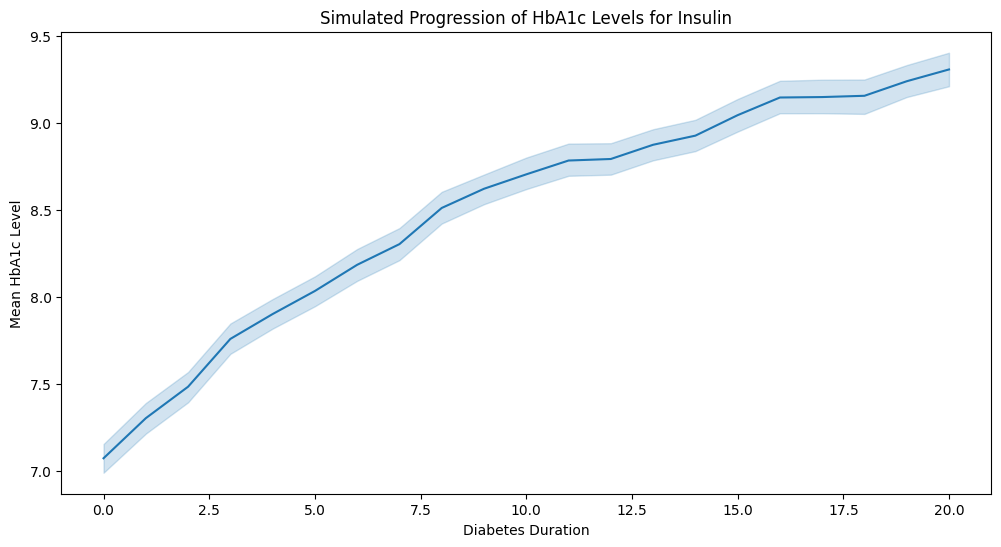

In [155]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', errorbar=('ci', 95), estimator='mean')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('Simulated Progression of HbA1c Levels for Insulin')
plt.grid(False)
plt.show()

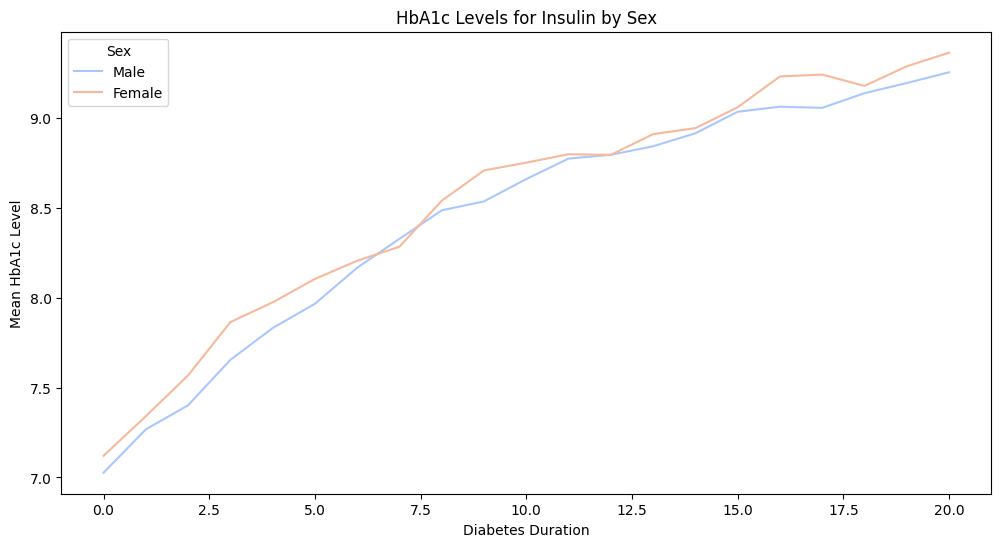

In [156]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Sex', errorbar=None, estimator='mean', palette='coolwarm')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('HbA1c Levels for Insulin by Sex')
plt.grid(False)
plt.legend(title='Sex', labels=sex_map.values())
plt.show()

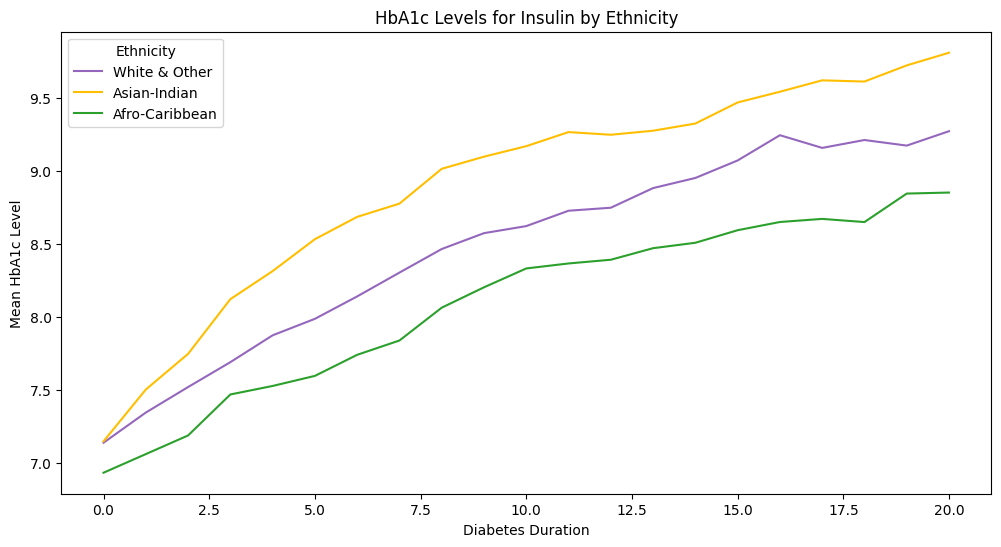

In [157]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Diabetes_Duration', y='HbA1c', hue='Ethnicity', errorbar=None, estimator='mean', 
             palette=custom_palette, hue_order=[0, 1, 2])
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean HbA1c Level')
plt.title('HbA1c Levels for Insulin by Ethnicity')
plt.grid(False)
plt.legend(
    title='Ethnicity',
    labels=[ethnicity_map[i] for i in [0, 1, 2]])
plt.show()

In [158]:
# ---------------------------------------------------------------------------
# Assumes `df` already exists in the notebook from the user's HbA1c simulation
# ---------------------------------------------------------------------------
try:
    df
except NameError:
    raise RuntimeError(
        "The DataFrame `df` was not found. "
        "Please run your HbA1c simulation code first, "
        "so that `df` containing the columns "
        "['Bootstrap', 'Year', 'Diabetes_Duration', 'Patient_ID', "
        "'Sex', 'Ethnicity', 'HbA1c'] is defined."
    )

# 1.  Screen HbA1c (H) per patient  ------------------------------------------
screen_H = (
    df.loc[df["Year"] == 1, ["Patient_ID", "HbA1c"]]
      .set_index("Patient_ID")["HbA1c"]
)

# 2.  Sort for cumulative calculations
df_sorted = df.sort_values(["Patient_ID", "Year"]).copy()

# 3.  Cumulative mean HbA1c (A) for each patient up to current year ----------
df_sorted["CumMean_HbA1c"] = (
    df_sorted.groupby("Patient_ID")["HbA1c"]
             .expanding()
             .mean()
             .reset_index(level=0, drop=True)
)

# 4.  Merge screen_H into df_sorted so every row has H ------------------------
df_sorted["Screen_HbA1c"] = df_sorted["Patient_ID"].map(screen_H)

# 5.  Hazard calculation parameters (DCCT Poisson model) ---------------------
ALPHA = -10.682
B1 = 0.201
B2 = 0.561
B3 = -1.228
B4 = 1.709
B5 = 0.686

# 6.  Compute hazard λ_it -----------------------------------------------------
#    D = Year, t = Diabetes_Duration, A = CumMean_HbA1c
ln_D = np.log(df_sorted["Year"])
ln_A = np.log(df_sorted["CumMean_HbA1c"])

df_sorted["Hazard"] = np.exp(
    ALPHA +
    B1 * df_sorted["Screen_HbA1c"] +
    B2 * ln_D +
    B3 * df_sorted["Diabetes_Duration"] +
    B4 * ln_A +
    B5 * df_sorted["Diabetes_Duration"] * ln_A
)

# 7.  Collect output DataFrame as requested -----------------------------------
hazard_df = df_sorted[[
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID",
    "Sex", "Ethnicity", "CumMean_HbA1c", "Hazard"
]].reset_index(drop=True)

# hazard_df.to_csv("hazard_df.csv", index=False)

In [159]:
# Compute average hazard rate per study year (diabetes duration)
avg_hazard_diabetes_duration = (
    hazard_df.groupby("Diabetes_Duration", as_index=False)["Hazard"]
             .mean()
             .rename(columns={"Hazard": "Mean_Hazard"})
)
print(avg_hazard_diabetes_duration)

    Diabetes_Duration  Mean_Hazard
0                   0     0.003262
1                   1     0.006018
2                   2     0.009496
3                   3     0.014466
4                   4     0.021351
5                   5     0.031523
6                   6     0.045950
7                   7     0.066890
8                   8     0.098350
9                   9     0.146553
10                 10     0.217140
11                 11     0.326144
12                 12     0.486367
13                 13     0.712891
14                 14     1.060073
15                 15     1.595531
16                 16     2.395290
17                 17     3.620362
18                 18     5.386180
19                 19     7.694057
20                 20    11.710326


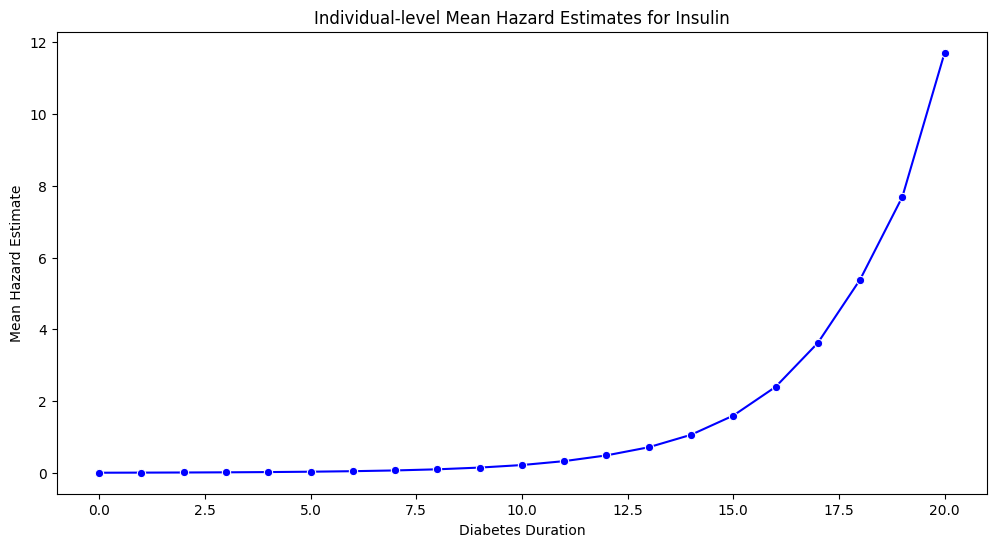

In [160]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_hazard_diabetes_duration, x='Diabetes_Duration', y='Mean_Hazard', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Hazard Estimate')
plt.title('Individual-level Mean Hazard Estimates for Insulin')
plt.grid(False)
plt.show()

In [161]:
# 1. Copy relevant columns so we keep the original frame intact
probability_df = hazard_df.copy()

# 2. Probability of disease event in year t for each patient
#    P = 1 - exp(-rate * time),  where time = Year (1…21) and rate = Hazard
probability_df["Probability"] = 1.0 - np.exp(
    - probability_df["Hazard"] * probability_df["Year"]
)

# 3. Keep only necessary columns (add others if you need them)
probability_df = probability_df[[
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID", "Probability"
]]

# probability_df.to_csv("probability_df.csv", index=False)

In [162]:
# Compute average probability per study year (diabetes duration)
avg_probability_diabetes_duration = (
    probability_df.groupby("Diabetes_Duration", as_index=False)["Probability"]
             .mean()
             .rename(columns={"Probability": "Mean_Probability"})
)
print(avg_probability_diabetes_duration)

    Diabetes_Duration  Mean_Probability
0                   0          0.003255
1                   1          0.011915
2                   2          0.027741
3                   3          0.054538
4                   4          0.094888
5                   5          0.152475
6                   6          0.224744
7                   7          0.309621
8                   8          0.404645
9                   9          0.503033
10                 10          0.594126
11                 11          0.675776
12                 12          0.742976
13                 13          0.799095
14                 14          0.842377
15                 15          0.875975
16                 16          0.903319
17                 17          0.925588
18                 18          0.941457
19                 19          0.955372
20                 20          0.965015


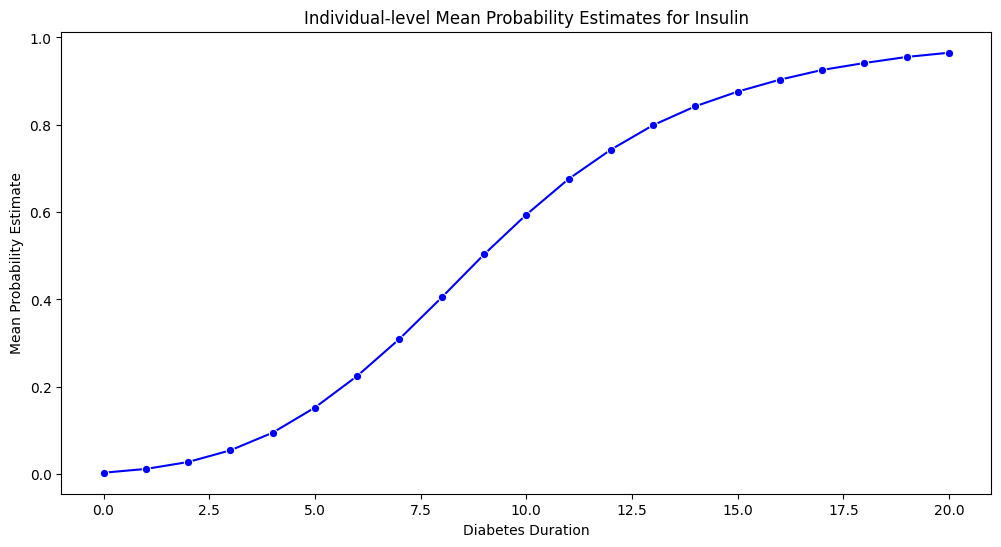

In [163]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_probability_diabetes_duration, x='Diabetes_Duration', y='Mean_Probability', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Probability Estimate')
plt.title('Individual-level Mean Probability Estimates for Insulin')
plt.grid(False)
plt.show()

In [164]:
# 1. Merge hazard rates with corresponding HbA1c values -----------------------
merged = (
    hazard_df.merge(
        df[["Bootstrap", "Year", "Patient_ID", "HbA1c"]],
        on=["Bootstrap", "Year", "Patient_ID"],
        how="left",
        validate="one_to_one",
        suffixes=("", "_RiskFactor")
    )
)

# 2. Sort for lag calculations -------------------------------------------------
merged = merged.sort_values(["Patient_ID", "Year"]).copy()

# 3. Add previous-year values within each patient -----------------------------
merged["Hazard_prev"] = merged.groupby("Patient_ID")["Hazard"].shift(1)
merged["HbA1c_prev"]  = merged.groupby("Patient_ID")["HbA1c"].shift(1)

# 4. Calculate beta (skip Year==1 where prev is NaN) ---------------------------
def safe_beta(row):
    h_prev, h_cur = row["Hazard_prev"], row["Hazard"]
    a_prev, a_cur = row["HbA1c_prev"], row["HbA1c"]
    if pd.isna(h_prev) or pd.isna(a_prev):
        return np.nan
    if a_cur == a_prev or h_prev <= 0 or h_cur <= 0:
        return np.nan
    return np.log(h_cur / h_prev) / np.log(a_cur / a_prev)

merged["Beta"] = merged.apply(safe_beta, axis=1)

# 5. Prepare final beta DataFrame (exclude Year 1) -----------------------------
beta_df = merged.loc[merged["Year"] > 1, [
    "Bootstrap", "Year", "Diabetes_Duration", "Patient_ID", "Beta"
]].reset_index(drop=True)

#beta_df.to_csv("beta_df.csv", index=False)

In [165]:
# Compute average beta values per study year (diabetes duration)
avg_beta_diabetes_duration = (
    beta_df.groupby("Diabetes_Duration", as_index=False)["Beta"]
             .mean()
             .rename(columns={"Beta": "Mean_Beta"})
)
print(avg_beta_diabetes_duration)

    Diabetes_Duration  Mean_Beta
0                   1  -0.298225
1                   2  -9.282184
2                   3   1.443176
3                   4   0.886121
4                   5   4.338697
5                   6   4.314956
6                   7   1.852258
7                   8  -0.928227
8                   9   3.904187
9                  10  -0.103637
10                 11   6.536006
11                 12  -0.856375
12                 13  -3.977314
13                 14  -0.290355
14                 15  -0.912180
15                 16   0.754934
16                 17   1.100921
17                 18 -31.710098
18                 19  -1.659515
19                 20   2.379985


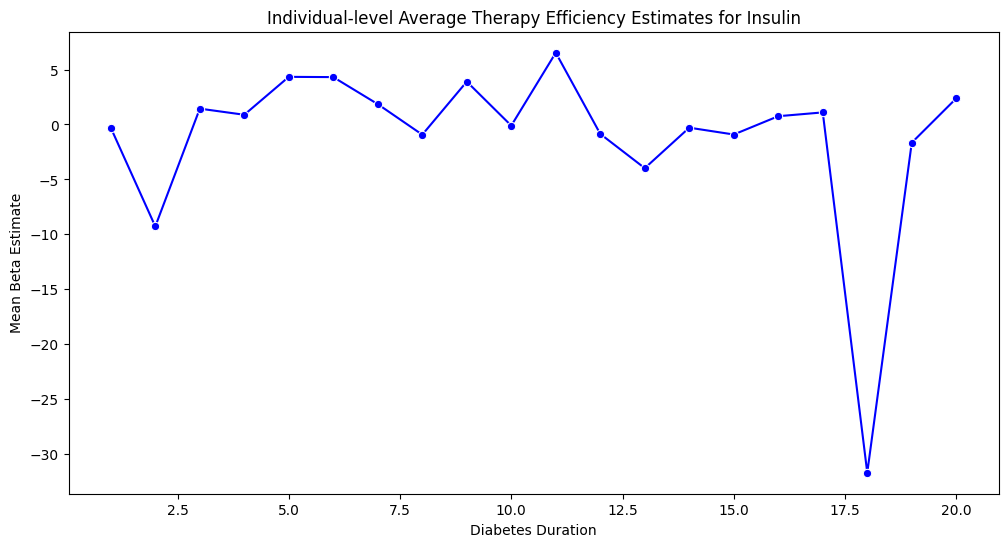

In [166]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_beta_diabetes_duration, x='Diabetes_Duration', y='Mean_Beta', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Beta Estimate')
plt.title('Individual-level Average Therapy Efficiency Estimates for Insulin')
plt.grid(False)
plt.show()

In [167]:
avg_df = avg_HbA1c_diabetes_duration.copy()

# harmonise column names
if "Avg_HbA1c" not in avg_df.columns:
    # try to detect the HbA1c column
    hba1c_col = [c for c in avg_df.columns if "HbA1c" in c][0]
    avg_df = avg_df.rename(columns={hba1c_col: "Avg_HbA1c"})

# Ensure Diabetes_Duration integer & sorted
avg_df["Diabetes_Duration"] = avg_df["Diabetes_Duration"].astype(int)
avg_df = avg_df.sort_values("Diabetes_Duration").reset_index(drop=True)

# ---------------------------------------------------------------------------
# 1. cumulative mean HbA1c (A) across durations for the population
avg_df["CumMean_HbA1c"] = avg_df["Avg_HbA1c"].expanding().mean()

# 2. baseline H (duration 0 average)
baseline_H = float(avg_df.loc[avg_df["Diabetes_Duration"] == 0, "Avg_HbA1c"].iloc[0])

# 3. Hazard calculation parameters
ALPHA = -10.682
B1 = 0.201
B2 = 0.561
B3 = -1.228
B4 = 1.709
B5 = 0.686

# 4. Calculate hazard for each duration
#    D = Year = duration + 1
avg_df["Year"] = avg_df["Diabetes_Duration"] + 1
avg_df["ln_D"] = np.log(avg_df["Year"])
avg_df["ln_A"] = np.log(avg_df["CumMean_HbA1c"])

avg_df["Hazard"] = np.exp(
    ALPHA +
    B1 * baseline_H +
    B2 * avg_df["ln_D"] +
    B3 * avg_df["Diabetes_Duration"] +
    B4 * avg_df["ln_A"] +
    B5 * avg_df["Diabetes_Duration"] * avg_df["ln_A"]
)

# 5. Beta calculation (skip first duration)
haz_prev = avg_df["Hazard"].shift(1)
Hb_prev  = avg_df["Avg_HbA1c"].shift(1)

beta_vals = np.where(
    (avg_df["Diabetes_Duration"] == 0) | (haz_prev <= 0) | (avg_df["Hazard"] <= 0) |
    (avg_df["Avg_HbA1c"] == Hb_prev),
    np.nan,
    np.log(avg_df["Hazard"] / haz_prev) / np.log(avg_df["Avg_HbA1c"] / Hb_prev)
)

avg_df["Beta"] = beta_vals

# Keep desired columns
pop_hazard_beta_df = avg_df[[
    "Diabetes_Duration", "Year", "Avg_HbA1c", "CumMean_HbA1c",
    "Hazard", "Beta"
]]

avg_df["Probability"] = 1.0 - np.exp(
    - pop_hazard_beta_df["Hazard"] * pop_hazard_beta_df["Year"]
)

pop_hazard_beta_df = avg_df[[
    "Diabetes_Duration", "Year", "Avg_HbA1c", "CumMean_HbA1c",
    "Hazard", "Probability", "Beta"
]]

print(pop_hazard_beta_df)

    Diabetes_Duration  Year  Avg_HbA1c  CumMean_HbA1c    Hazard  Probability  \
0                   0     1   7.073499       7.073499  0.002694     0.002690   
1                   1     2   7.303898       7.188698  0.004630     0.009217   
2                   2     3   7.484855       7.287417  0.006870     0.020399   
3                   3     4   7.759662       7.405479  0.009812     0.038488   
4                   4     5   7.902639       7.504911  0.013649     0.065971   
5                   5     6   8.035248       7.593300  0.018743     0.106366   
6                   6     7   8.185810       7.677944  0.025651     0.164360   
7                   7     8   8.304688       7.756287  0.035019     0.244334   
8                   8     9   8.512571       7.840319  0.048270     0.352365   
9                   9    10   8.622923       7.918579  0.066611     0.486299   
10                 10    11   8.705789       7.990144  0.091920     0.636189   
11                 11    12   8.785262  

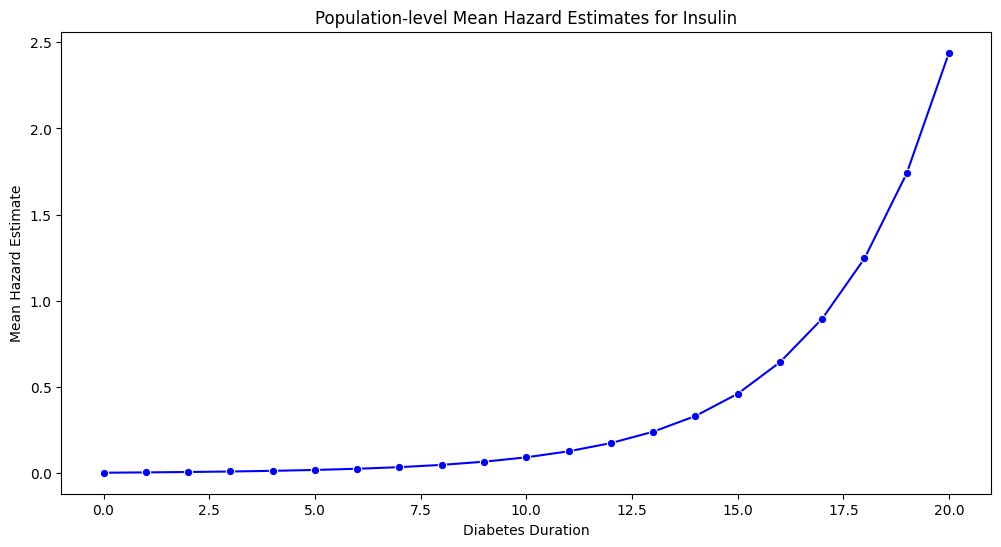

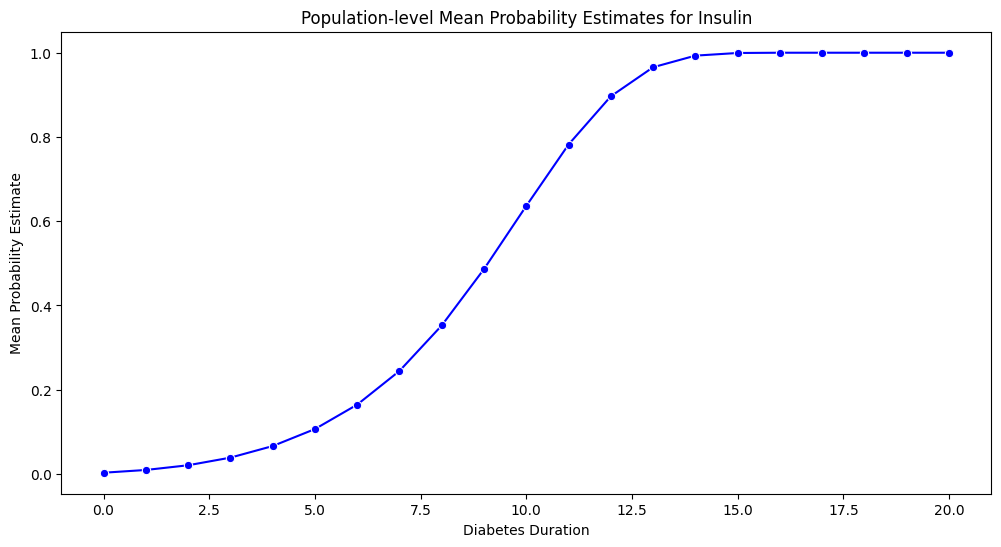

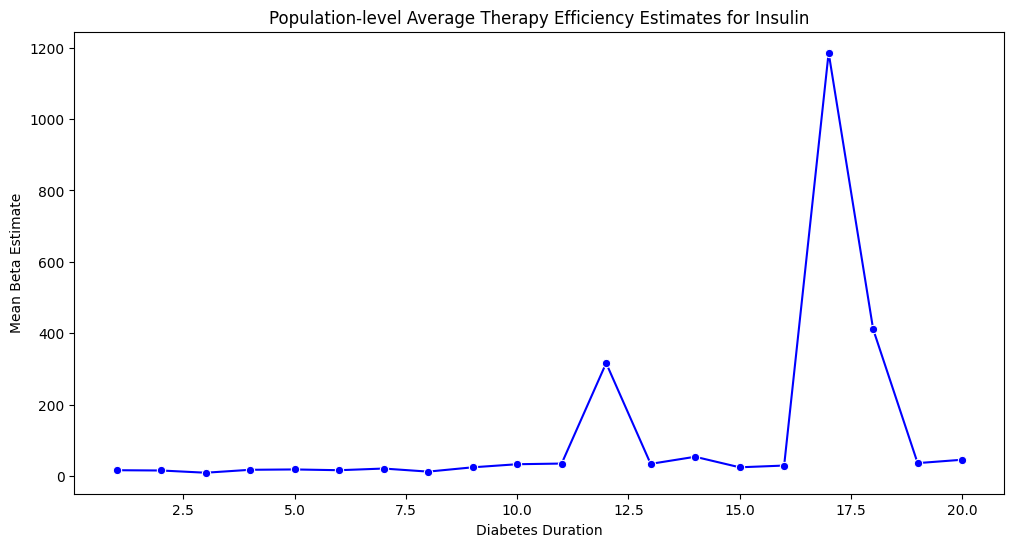

In [168]:
# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Hazard', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Hazard Estimate')
plt.title('Population-level Mean Hazard Estimates for Insulin')
plt.grid(False)
plt.show()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Probability', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Probability Estimate')
plt.title('Population-level Mean Probability Estimates for Insulin')
plt.grid(False)
plt.show()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=pop_hazard_beta_df, x='Diabetes_Duration', y='Beta', marker='o', color='b')
plt.xlabel('Diabetes Duration')
plt.ylabel('Mean Beta Estimate')
plt.title('Population-level Average Therapy Efficiency Estimates for Insulin')
plt.grid(False)
plt.show()